# RA hand X-ray severity grading (Mild / Moderate / Severe)


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, f1_score, recall_score,
                             classification_report, accuracy_score,
                             cohen_kappa_score, roc_auc_score, balanced_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
from warnings import filterwarnings
filterwarnings('ignore')
import json, os, re
from pathlib import Path
from PIL import Image
import pandas as pd
import copy, math, itertools


In [2]:
import random

SEED = 42

def seed_all(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(SEED)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
imgSize = 384
root = "/content/rheumatoid_arthritis/dataset"   # raw Kaggle dataset
SRC_ROOT = root                                   # always the RAW data (never overwritten later)


In [5]:
!pip install -q kaggle
from google.colab import files
uploaded = files.upload()

Saving kaggle (1).json to kaggle (1) (1).json


In [6]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)

_up = globals().get("uploaded") or {}
if _up:
    _kname = next(iter(_up))
    shutil.copy(_kname, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("Kaggle key installed from:", _kname)
elif os.path.exists('/root/.kaggle/kaggle.json'):
    print("Kaggle key already present.")
else:
    raise FileNotFoundError("No kaggle.json uploaded: run the cell above and choose your kaggle.json file.")


Kaggle key installed from: kaggle (1) (1).json


In [7]:
!kaggle datasets download -d sindhuvunna/rheumatoid-arthritis-detection
import zipfile
with zipfile.ZipFile('/content/rheumatoid-arthritis-detection.zip', 'r') as z:
    z.extractall('/content/rheumatoid_arthritis')
print("Dataset extracted.")

Dataset URL: https://www.kaggle.com/datasets/sindhuvunna/rheumatoid-arthritis-detection
License(s): unknown
rheumatoid-arthritis-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset extracted.


---
# Preprocessing section



In [8]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import subprocess, sys, glob, shutil, time, math
import cv2
from concurrent.futures import ThreadPoolExecutor
DATA_VARIANT = "roi"
WORK_DIR  = "/content/ra_preproc"
CLAHE_CLIP   = 2.0
CLAHE_TILE   = 8
LONG_SIDE    = None
JPEG_QUALITY = 95
SKIP_CLASSES = []
# --- YOLO joint detector
DETECTOR_WEIGHTS = "/content/drive/MyDrive/ra_xray_yolo/joint_detector_best.pt"

# Your YOLO was trained on the original/raw X-ray images
DETECT_ON = "raw"

YOLO_IMGSZ = 640
CONF_MIN   = 0.25
CONF_ROI   = 0.50
ROI_PAD    = 0.10
SAVE_PATCHES = False
PATCH_SIZE, PATCH_CONF, PATCH_PAD = 128, 0.90, 0.25



assert DATA_VARIANT in ("raw", "clahe", "roi"), "DATA_VARIANT must be raw, clahe or roi"
assert os.path.isdir(SRC_ROOT), f"{SRC_ROOT} not found - run the Kaggle download cells above first"

SPLITS     = ["train", "val", "test"]
IMG_EXT    = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
OUT_CLAHE  = f"{WORK_DIR}/clahe/dataset"
OUT_ROI    = f"{WORK_DIR}/clahe_roi/dataset"
OUT_PATCH  = f"{WORK_DIR}/joint_patches"
BOXES_CSV  = f"{WORK_DIR}/joint_boxes.csv"
os.makedirs(WORK_DIR, exist_ok=True)

def list_images(root_dir, splits=SPLITS, skip=SKIP_CLASSES):
    """Return a DataFrame: split, label, rel (path relative to root_dir)."""
    rows_ = []
    for s in splits:
        for cls in sorted(os.listdir(os.path.join(root_dir, s))):
            d = os.path.join(root_dir, s, cls)
            if not os.path.isdir(d) or cls in skip:
                continue
            for f in sorted(os.listdir(d)):
                if Path(f).suffix.lower() in IMG_EXT:
                    rows_.append((s, cls, f"{s}/{cls}/{f}"))
    return pd.DataFrame(rows_, columns=["split", "label", "rel"])

src_df = list_images(SRC_ROOT)
print(f"DATA_VARIANT = {DATA_VARIANT}")
print(src_df.groupby(["split", "label"]).size().unstack(fill_value=0))

DATA_VARIANT = roi
label  Mild  Moderate  Normal  Severe
split                                
test    242       103     610      87
train  1123       472    2841     401
val     240       101     608      85


##  CLAHE



In [10]:
def load_gray(path, long_side=LONG_SIDE):
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        img = np.array(Image.open(path).convert("L"))
    if img.ndim == 3:
        img = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if long_side and max(img.shape) > long_side:
        s = long_side / max(img.shape)
        img = cv2.resize(img, (round(img.shape[1] * s), round(img.shape[0] * s)), interpolation=cv2.INTER_AREA)
    return img

def apply_clahe(gray, clip=CLAHE_CLIP, tile=CLAHE_TILE):
    return cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(gray)

def preprocess(path):
    return apply_clahe(load_gray(path))

def save_jpg(gray, out_path, quality=JPEG_QUALITY):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    cv2.imwrite(out_path, cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR), [cv2.IMWRITE_JPEG_QUALITY, quality])

def clahe_name(rel):
    return str(Path(rel).with_suffix(".jpg"))

In [11]:
if not (DATA_VARIANT != "raw"):
    print("skipped (DATA_VARIANT is raw)")
else:
    def _do(rel):
        out = os.path.join(OUT_CLAHE, clahe_name(rel))
        if os.path.exists(out):
            return "skipped"
        try:
            save_jpg(preprocess(os.path.join(SRC_ROOT, rel)), out)
            return "ok"
        except Exception as e:
            return f"FAILED {rel}: {e}"

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=4) as ex:
        results = list(tqdm(ex.map(_do, src_df.rel), total=len(src_df), desc="CLAHE"))
    fails = [r for r in results if r.startswith("FAILED")]
    print(f"done in {(time.time()-t0)/60:.1f} min | ok {results.count('ok')} | skipped {results.count('skipped')} | failed {len(fails)}")
    for f in fails[:10]: print(" ", f)

    out_df = list_images(OUT_CLAHE)
    print(out_df.groupby(["split", "label"]).size().unstack(fill_value=0))
    assert len(out_df) == len(src_df) - len(fails), "image count differs from the source"

CLAHE:   0%|          | 0/6913 [00:00<?, ?it/s]

done in 0.0 min | ok 0 | skipped 6913 | failed 0
label  Mild  Moderate  Normal  Severe
split                                
test    242       103     610      87
train  1123       472    2841     401
val     240       101     608      85


##  YOLO joint detector



In [12]:

if DATA_VARIANT == "roi":
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=False)
    print("ultralytics ready")
else:
    print("skipped (DATA_VARIANT is not roi)")

ultralytics ready


In [13]:

ANNOT_IMAGES = "/content/annotated/images"
ANNOT_LABELS = "/content/annotated/labels"
CLASS_NAMES = [
    "DIP",
    "MCP",
    "PIP",
    "Radius",
    "Ulna",
    "Wrist"
]
TRAIN_VARIANTS = ["clahe", "raw"]
YOLO_BASE    = "yolov8n.pt"
EPOCHS, BATCH = 100, 8
VAL_FRACTION  = 0.2

def build_yolo_dataset(variant):
    base = Path(WORK_DIR) / f"yolo_{variant}"
    imgs = sorted(p for p in Path(ANNOT_IMAGES).iterdir() if p.suffix.lower() in IMG_EXT)
    assert imgs, f"no images in {ANNOT_IMAGES}"
    rng = random.Random(SEED); rng.shuffle(imgs)
    n_val = max(1, round(len(imgs) * VAL_FRACTION))
    split = {"val": imgs[:n_val], "train": imgs[n_val:]}
    for s, files_ in split.items():
        (base / "images" / s).mkdir(parents=True, exist_ok=True)
        (base / "labels" / s).mkdir(parents=True, exist_ok=True)
        for p in files_:
            lab = Path(ANNOT_LABELS) / (p.stem + ".txt")
            if not lab.exists():
                print("no label for", p.name, "- skipped"); continue
            out = base / "images" / s / (p.stem + ".jpg")
            if variant == "clahe":
                save_jpg(preprocess(p), str(out))
            else:
                save_jpg(load_gray(p), str(out))
            shutil.copy(lab, base / "labels" / s / (p.stem + ".txt"))
    yaml_path = base / "data.yaml"
    yaml_path.write_text(f"path: {base}\ntrain: images/train\nval: images/val\nnames:\n" +
                         "".join(f"  {i}: {n}\n" for i, n in enumerate(CLASS_NAMES)))
    print(f"{variant}: {len(split['train'])} train / {len(split['val'])} val images -> {yaml_path}")
    return str(yaml_path)

In [14]:
if not (DATA_VARIANT == "roi"):
    print("skipped (DATA_VARIANT is not roi)")
else:

    from ultralytics import YOLO
    import torch

    det_rows, det_weights = [], {}
    if DETECTOR_WEIGHTS is None:
        for v in TRAIN_VARIANTS:
            data_yaml = build_yolo_dataset(v)
            m = YOLO(YOLO_BASE)
            m.train(data=data_yaml, imgsz=YOLO_IMGSZ, epochs=EPOCHS, batch=BATCH, workers=2,
                    patience=30, seed=SEED, deterministic=True, project=f"{WORK_DIR}/runs", name=f"joint_{v}",
                    exist_ok=True, verbose=False)
            best = f"{WORK_DIR}/runs/joint_{v}/weights/best.pt"
            met = YOLO(best).val(data=data_yaml, imgsz=YOLO_IMGSZ, verbose=False)
            ap = met.box.all_ap                      # [classes, 10] = AP at IoU 0.50, 0.55, ... 0.95
            det_rows.append({"variant": v, "precision": float(met.box.mp), "recall": float(met.box.mr),
                             "mAP@0.50": float(ap[:, 0].mean()), "mAP@0.75": float(ap[:, 5].mean()),
                             "mAP@0.50:0.95": float(met.box.map)})
            det_weights[v] = best
            del m; torch.cuda.empty_cache()
        det_table = pd.DataFrame(det_rows).set_index("variant")
        print(det_table.round(4))
        best_variant = det_table["mAP@0.75"].idxmax()
        DETECTOR_WEIGHTS, DETECT_ON = det_weights[best_variant], best_variant
        print(f"\nUsing the '{best_variant}' detector: {DETECTOR_WEIGHTS}   (DETECT_ON = '{DETECT_ON}')")
    else:
        print("Using your weights:", DETECTOR_WEIGHTS, "| DETECT_ON =", DETECT_ON)

Using your weights: /content/drive/MyDrive/ra_xray_yolo/joint_detector_best.pt | DETECT_ON = raw


##  detect joints in every image



In [15]:
if not (DATA_VARIANT == "roi"):
    print("skipped (DATA_VARIANT is not roi)")
else:
    from ultralytics import YOLO
    det = YOLO(DETECTOR_WEIGHTS)
    det_root = OUT_CLAHE if DETECT_ON == "clahe" else SRC_ROOT
    det_df = list_images(det_root)
    det_df["key"] = det_df.rel.str.replace(r"\.[^.]+$", "", regex=True)

    done = set()
    if os.path.exists(BOXES_CSV):
        old = pd.read_csv(BOXES_CSV)
        done = set(old["key"].unique())
        print(f"resuming: {len(done)} images already processed")
    todo = det_df[~det_df.key.isin(done)].reset_index(drop=True)
    print(f"{len(todo)} images to detect")

    CHUNK = 128
    header_needed = not os.path.exists(BOXES_CSV)
    for i in tqdm(range(0, len(todo), CHUNK), desc="detecting"):
        part = todo.iloc[i:i + CHUNK]
        paths = [os.path.join(det_root, r) for r in part.rel]
        rows = []
        for (_, meta), r in zip(part.iterrows(), det.predict(paths, imgsz=YOLO_IMGSZ, conf=CONF_MIN,
                                                             max_det=60, stream=True, verbose=False)):
            h, w = r.orig_shape
            b = r.boxes
            if len(b) == 0:
                rows.append(dict(split=meta.split, label=meta.label, key=meta.key, k=-1, x1=np.nan, y1=np.nan,
                                 x2=np.nan, y2=np.nan, conf=np.nan, cls=-1, W=w, H=h))
                continue
            xyxyn, conf, cls = b.xyxyn.cpu().numpy(), b.conf.cpu().numpy(), b.cls.cpu().numpy()
            for k in range(len(b)):
                rows.append(dict(split=meta.split, label=meta.label, key=meta.key, k=k,
                                 x1=xyxyn[k, 0], y1=xyxyn[k, 1], x2=xyxyn[k, 2], y2=xyxyn[k, 3],
                                 conf=float(conf[k]), cls=int(cls[k]), W=w, H=h))
        pd.DataFrame(rows).to_csv(BOXES_CSV, mode="a", header=header_needed, index=False)
        header_needed = False

    boxes = pd.read_csv(BOXES_CSV)
    print("boxes saved to", BOXES_CSV, "| rows:", len(boxes))

resuming: 6913 images already processed
0 images to detect


detecting: 0it [00:00, ?it/s]

boxes saved to /content/ra_preproc/joint_boxes.csv | rows: 165229


In [16]:
if not (DATA_VARIANT == "roi"):
    print("skipped (DATA_VARIANT is not roi)")
else:

    boxes = pd.read_csv(BOXES_CSV)
    valid = boxes[boxes.k >= 0]
    n_conf = valid[valid.conf >= CONF_ROI].groupby("key").size()
    summary = (boxes.drop_duplicates("key")[["key", "split", "label"]]
               .assign(n_joints=lambda d: d.key.map(n_conf).fillna(0).astype(int)))
    print(summary.groupby("label").n_joints.describe()[["count", "mean", "min", "50%", "max"]].round(1))
    print("\nimages with NO joint at conf >= %.2f: %d of %d" % (CONF_ROI, (summary.n_joints == 0).sum(), len(summary)))

           count  mean  min   50%   max
label                                  
Mild      1605.0  31.4  0.0  33.0  37.0
Moderate   676.0  31.1  0.0  32.0  38.0
Normal    4059.0  13.4  0.0  14.0  35.0
Severe     573.0  29.4  0.0  31.0  38.0

images with NO joint at conf >= 0.50: 55 of 6913


##  hand-ROI dataset and optional joint patches



In [17]:
ROI_CLASS_IDS = {0, 1, 2, 5}

def union_roi(df_img, w, h, conf_min=CONF_ROI, pad=ROI_PAD):
    """ROI from confident DIP/MCP/PIP/Wrist detections."""

    d = df_img[
        (df_img.k >= 0) &
        (df_img.conf >= conf_min) &
        (df_img.cls.isin(ROI_CLASS_IDS))
    ]

    if d.empty:
        return None

    x1 = d.x1.min() * w
    y1 = d.y1.min() * h
    x2 = d.x2.max() * w
    y2 = d.y2.max() * h

    px = (x2 - x1) * pad
    py = (y2 - y1) * pad

    x1 = max(0, x1 - px)
    y1 = max(0, y1 - py)
    x2 = min(w, x2 + px)
    y2 = min(h, y2 + py)

    if x2 - x1 < 8 or y2 - y1 < 8:
        return None

    return (
        int(round(x1)),
        int(round(y1)),
        int(round(x2)),
        int(round(y2))
    )

def build_roi_dataset(boxes_df, clahe_root, out_root):
    fallbacks, n = [], 0
    for key, g in tqdm(boxes_df.groupby("key"), desc="ROI crops"):
        src = None
        for ext in (".jpg", ".jpeg", ".png"):
            if os.path.exists(os.path.join(clahe_root, key + ext)):
                src = os.path.join(clahe_root, key + ext); break
        if src is None:
            fallbacks.append((key, "missing CLAHE image")); continue
        img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
        h, w = img.shape
        box = union_roi(g, w, h)
        if box is None:
            fallbacks.append((key, "no confident joint - kept whole image"))
            crop = img
        else:
            crop = img[box[1]:box[3], box[0]:box[2]]
        save_jpg(crop, os.path.join(out_root, key + ".jpg")); n += 1
    pd.DataFrame(fallbacks, columns=["key", "reason"]).to_csv(os.path.join(os.path.dirname(out_root), "roi_fallbacks.csv"), index=False)
    return n, len(fallbacks)

In [18]:
if not (DATA_VARIANT == "roi"):
    print("skipped (DATA_VARIANT is not roi)")
else:
    assert os.path.isdir(OUT_CLAHE), "run Part 1 first (the ROI crops are cut from the CLAHE images)"
    n, nf = build_roi_dataset(pd.read_csv(BOXES_CSV), OUT_CLAHE, OUT_ROI)
    print(f"ROI images written: {n} | fell back to the whole image: {nf}")
    print(list_images(OUT_ROI).groupby(["split", "label"]).size().unstack(fill_value=0))

ROI crops:   0%|          | 0/6913 [00:00<?, ?it/s]

ROI images written: 6913 | fell back to the whole image: 58
label  Mild  Moderate  Normal  Severe
split                                
test    242       103     610      87
train  1123       472    2841     401
val     240       101     608      85


In [19]:
def square_patch(img, box_n, size=PATCH_SIZE, pad=PATCH_PAD):
    h, w = img.shape
    cx, cy = (box_n[0] + box_n[2]) / 2 * w, (box_n[1] + box_n[3]) / 2 * h
    side = max((box_n[2] - box_n[0]) * w, (box_n[3] - box_n[1]) * h) * (1 + pad)
    side = max(side, 16)
    x1, y1 = int(round(cx - side / 2)), int(round(cy - side / 2))
    x2, y2 = int(round(x1 + side)), int(round(y1 + side))
    pad_l, pad_t, pad_r, pad_b = max(0, -x1), max(0, -y1), max(0, x2 - w), max(0, y2 - h)
    crop = img[max(0, y1):min(h, y2), max(0, x1):min(w, x2)]
    if pad_l or pad_t or pad_r or pad_b:
        crop = cv2.copyMakeBorder(crop, pad_t, pad_b, pad_l, pad_r, cv2.BORDER_REPLICATE)
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)

def build_patches(boxes_df, clahe_root, out_root, conf_min=PATCH_CONF):
    meta = []
    d = boxes_df[(boxes_df.k >= 0) & (boxes_df.conf >= conf_min)]
    for key, g in tqdm(d.groupby("key"), desc="patches"):
        src = next((os.path.join(clahe_root, key + e) for e in (".jpg", ".jpeg", ".png")
                    if os.path.exists(os.path.join(clahe_root, key + e))), None)
        if src is None: continue
        img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
        for _, r in g.iterrows():
            p = square_patch(img, (r.x1, r.y1, r.x2, r.y2))
            rel = f"{r.split}/{r.label}/{Path(key).name}_j{int(r.k):02d}.png"
            os.makedirs(os.path.dirname(os.path.join(out_root, rel)), exist_ok=True)
            cv2.imwrite(os.path.join(out_root, rel), p)
            meta.append(dict(patch=rel, image=key, split=r.split, inherited_label=r.label, conf=r.conf, joint_k=int(r.k)))
    pd.DataFrame(meta).to_csv(os.path.join(out_root, "patch_metadata.csv"), index=False)
    return len(meta)

In [20]:
if not (DATA_VARIANT == "roi"):
    print("skipped (DATA_VARIANT is not roi)")
else:
    if SAVE_PATCHES:
        print("patches written:", build_patches(pd.read_csv(BOXES_CSV), OUT_CLAHE, OUT_PATCH))
    else:
        print("SAVE_PATCHES is False - skipped.")

SAVE_PATCHES is False - skipped.


In [21]:
if DATA_VARIANT == "clahe":
    root = OUT_CLAHE
elif DATA_VARIANT == "roi":
    root = OUT_ROI
else:
    root = SRC_ROOT
DATA_TAG = {"raw": "", "clahe": "_clahe", "roi": "_roi"}[DATA_VARIANT]

for s in SPLITS:
    assert os.path.isdir(os.path.join(root, s)), f"{root}/{s} is missing - run the preprocessing cells above first"
print("classifier data root:", root)
print("run-name tag:", repr(DATA_TAG))

classifier data root: /content/ra_preproc/clahe_roi/dataset
run-name tag: '_roi'


In [22]:
trainData = datasets.ImageFolder(root + '/train', transform=transforms.ToTensor())
valData = datasets.ImageFolder(root + '/val', transform=transforms.ToTensor())
testData = datasets.ImageFolder(root + '/test', transform=transforms.ToTensor())

print("Classes:", trainData.classes)
print(f"Train: {len(trainData)}, Val: {len(valData)}, Test: {len(testData)}")
assert trainData.classes == valData.classes == testData.classes, "class mismatch"

Classes: ['Mild', 'Moderate', 'Normal', 'Severe']
Train: 4837, Val: 1034, Test: 1042


In [23]:
def make_grading(ds):
    keep = [c for c in ds.classes if c != "Normal"]
    remap = {ds.class_to_idx[c]: i for i, c in enumerate(keep)}
    ds.samples = [(p, remap[y]) for p, y in ds.samples if y in remap]
    ds.targets = [y for _, y in ds.samples]
    ds.classes = keep
    ds.class_to_idx = {c: i for i, c in enumerate(keep)}
    return ds

trainData, valData, testData = map(make_grading, (trainData, valData, testData))
print(f"Classes: {trainData.classes}")
print(f"Sizes: train {len(trainData)}, val {len(valData)}, test {len(testData)}")
print(f"Train distribution: {np.bincount(trainData.targets)}")

Classes: ['Mild', 'Moderate', 'Severe']
Sizes: train 1996, val 426, test 432
Train distribution: [1123  472  401]


In [24]:
def compute_mean_std(samples, size):
    s, s2 = torch.zeros(3), torch.zeros(3)
    for path, _ in tqdm(samples, desc="computing mean/std", leave=False):
        im = Image.open(path)
        im.draft("RGB", (size * 2, size * 2))
        x = transforms.functional.to_tensor(im.convert("RGB").resize((size, size)))
        s += x.mean((1, 2))
        s2 += (x ** 2).mean((1, 2))
    mean = s / len(samples)
    std = (s2 / len(samples) - mean ** 2).sqrt()
    return mean.tolist(), std.tolist()

mean, std = compute_mean_std(trainData.samples, imgSize)
print(f"Computed mean: {[round(v, 4) for v in mean]}")
print(f"Computed std:  {[round(v, 4) for v in std]}")

computing mean/std:   0%|          | 0/1996 [00:00<?, ?it/s]

Computed mean: [0.3125, 0.3125, 0.3125]
Computed std:  [0.2685, 0.2685, 0.2685]


In [25]:
class RandomAffineBG:
    """Random affine whose empty border is filled with the image's own background grey."""

    def __init__(self, degrees, translate, scale, shear=None):
        self.degrees = degrees
        self.translate = translate
        self.scale = scale
        self.shear = shear

    def __call__(self, img):
        arr = np.asarray(img)
        border = np.concatenate([arr[0], arr[-1], arr[:, 0], arr[:, -1]])
        fill = tuple(int(v) for v in np.median(border, axis=0))
        angle, shift, scl, shr = transforms.RandomAffine.get_params(
            [-self.degrees, self.degrees], self.translate, self.scale,
            list(self.shear) if self.shear else None, list(img.size)
        )
        return transforms.functional.affine(
            img, angle, shift, scl, shr,
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=fill
        )


USE_HFLIP = True

train_aug = [transforms.Resize((imgSize, imgSize), antialias=True)]
if USE_HFLIP:
    train_aug.append(transforms.RandomHorizontalFlip(p=0.5))
train_aug += [
    RandomAffineBG(degrees=12, translate=(0.06, 0.06), scale=(0.88, 1.12), shear=(-4, 4)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.0))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.2, scale=(0.01, 0.04), ratio=(0.3, 3.3), value=0),
]
transformer = transforms.Compose(train_aug)

valTransformer = transforms.Compose([
    transforms.Resize((imgSize, imgSize), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

trainData.transform = transformer
valData.transform = valTransformer
testData.transform = valTransformer

print("Train augmentation:")
print(transformer)


Train augmentation:
Compose(
    Resize(size=(384, 384), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.75, 1.25), contrast=(0.75, 1.25), saturation=None, hue=None)
    RandomApply(
    p=0.2
    GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 1.0))
)
    ToTensor()
    Normalize(mean=[0.3124961853027344, 0.3124961853027344, 0.3124961853027344], std=[0.26851701736450195, 0.26851701736450195, 0.26851701736450195])
    RandomErasing(p=0.2, scale=(0.01, 0.04), ratio=(0.3, 3.3), value=0, inplace=False)
)


In [26]:
train_labels = np.array(trainData.targets)
class_counts = np.bincount(train_labels, minlength=len(trainData.classes))

class_weights = torch.tensor(
    compute_class_weight("balanced", classes=np.arange(len(trainData.classes)), y=train_labels),
    dtype=torch.float32
)

# SAMPLER_POWER = 1.0 -> perfectly balanced batches (rare images repeated ~1.5x per epoch -> memorisation)
# SAMPLER_POWER = 0.0 -> natural class frequencies
# 0.5 keeps minority grades visible without over-repeating them; the decision cut-points are re-calibrated
# on the validation set after training, which removes the remaining prior shift.
SAMPLER_POWER = 0.5
sampling_weights = 1.0 / np.power(class_counts.astype(np.float64), SAMPLER_POWER)
train_sample_weights = torch.as_tensor(sampling_weights[train_labels], dtype=torch.double)
train_sampler = WeightedRandomSampler(train_sample_weights, num_samples=len(train_labels), replacement=True)

expected_share = (class_counts * sampling_weights) / (class_counts * sampling_weights).sum()
print(f"Class counts: {dict(zip(trainData.classes, class_counts.tolist()))}")
print(f"Expected share of each grade per epoch: {dict(zip(trainData.classes, np.round(expected_share, 3).tolist()))}")


Class counts: {'Mild': 1123, 'Moderate': 472, 'Severe': 401}
Expected share of each grade per epoch: {'Mild': 0.445, 'Moderate': 0.289, 'Severe': 0.266}


In [27]:
batchSize = 16

trainLoader = DataLoader(trainData, batch_size=batchSize, sampler=train_sampler, drop_last=True,
                         num_workers=2, pin_memory=torch.cuda.is_available(), persistent_workers=True)
valLoader = DataLoader(valData, batch_size=batchSize, shuffle=False,
                       num_workers=2, pin_memory=torch.cuda.is_available())
testLoader = DataLoader(testData, batch_size=batchSize, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())

print(f"Loaders created: {len(trainLoader)} / {len(valLoader)} / {len(testLoader)} batches")


Loaders created: 124 / 27 / 27 batches


## Manual image upload: see the result of every preprocessing step
Run the next two cells to upload **one or more** hand X-rays and look at every stage
(original → CLAHE → YOLO joints → ROI crop → model input → training-augmentation samples).
Run the second cell again whenever you want to upload a new set of images.


In [28]:
# ---------- manual upload + step-by-step transformation viewer ----------
UPLOAD_DIR = "/content/manual_uploads" if os.path.isdir("/content") else "./manual_uploads"
MANUAL_PATHS = []        # outside Colab: list your own file paths here, e.g. ["/data/a.jpg", "/data/b.png"]
SHOW_TRAIN_AUG = True    # also show random training augmentations of each uploaded image
N_AUG_SAMPLES = 2

_MEAN_T = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
_STD_T = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)


def tensor_to_rgb(x):
    """Undo Normalize so the model input can be displayed."""
    return (x.detach().cpu() * _STD_T + _MEAN_T).clamp(0, 1).permute(1, 2, 0).numpy()


def collect_uploads():
    """Colab: opens the file picker (select several files). Elsewhere: uses MANUAL_PATHS."""
    os.makedirs(UPLOAD_DIR, exist_ok=True)
    paths = []
    try:
        from google.colab import files as _colab_files
        print("Choose one or more X-ray images (hold Ctrl / Shift to select several)...")
        uploaded_ = _colab_files.upload()
        for name_, data_ in uploaded_.items():
            p_ = os.path.join(UPLOAD_DIR, os.path.basename(name_))
            with open(p_, "wb") as f_:
                f_.write(data_)
            paths.append(p_)
    except ImportError:
        paths = [str(p_) for p_ in MANUAL_PATHS]
    ok_ = [p_ for p_ in paths if Path(p_).suffix.lower() in IMG_EXT and os.path.isfile(p_)]
    for p_ in paths:
        if p_ not in ok_:
            print("skipped (not an image file):", p_)
    return ok_


_det_model = None


def get_detector():
    global _det_model
    if _det_model is None:
        _det_model = globals().get("det")
        if _det_model is None:
            from ultralytics import YOLO
            _det_model = YOLO(str(DETECTOR_WEIGHTS))
    return _det_model


def jpeg_roundtrip(gray, quality=JPEG_QUALITY):
    """Same JPEG compression the dataset build applies when it saves an image."""
    ok_, buf_ = cv2.imencode(".jpg", cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR), [cv2.IMWRITE_JPEG_QUALITY, quality])
    return cv2.imdecode(buf_, cv2.IMREAD_GRAYSCALE)


JOINT_COLS = ["k", "x1", "y1", "x2", "y2", "conf", "cls"]


def detect_joints(img_gray):
    result_ = get_detector().predict(cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR), imgsz=YOLO_IMGSZ,
                                     conf=CONF_MIN, max_det=60, verbose=False)[0]
    b_ = result_.boxes
    rows_ = []
    if len(b_):
        xyxyn_, conf_, cls_ = b_.xyxyn.cpu().numpy(), b_.conf.cpu().numpy(), b_.cls.cpu().numpy()
        for k_ in range(len(b_)):
            rows_.append(dict(k=k_, x1=float(xyxyn_[k_, 0]), y1=float(xyxyn_[k_, 1]), x2=float(xyxyn_[k_, 2]),
                              y2=float(xyxyn_[k_, 3]), conf=float(conf_[k_]), cls=int(cls_[k_])))
    return pd.DataFrame(rows_, columns=JOINT_COLS)


def run_pipeline(path):
    """Apply EXACTLY the preprocessing used to build the training data, keeping every intermediate image."""
    st = {"path": path, "name": os.path.basename(path), "notes": []}
    raw = load_gray(path)
    st["raw"] = raw
    final = raw
    if DATA_VARIANT in ("clahe", "roi"):
        clahe_img = jpeg_roundtrip(apply_clahe(raw))
        st["clahe"] = clahe_img
        final = clahe_img
        if DATA_VARIANT == "roi":
            boxes_df = detect_joints(raw if DETECT_ON == "raw" else clahe_img)
            st["boxes"] = boxes_df
            st["n_joints"] = int((boxes_df.conf >= CONF_ROI).sum()) if len(boxes_df) else 0
            H_, W_ = clahe_img.shape
            box_ = union_roi(boxes_df, W_, H_) if len(boxes_df) else None
            st["roi_box"] = box_
            if box_ is None:
                st["notes"].append("no confident joint found: whole image kept (same fallback as in training)")
                crop_ = clahe_img
            else:
                crop_ = clahe_img[box_[1]:box_[3], box_[0]:box_[2]]
            final = jpeg_roundtrip(crop_)
            st["roi"] = final
            if st["n_joints"] == 0:
                st["notes"].append("WARNING: 0 joints detected - this may not be a hand/wrist X-ray")
    st["final"] = final
    st["pil"] = Image.fromarray(cv2.cvtColor(final, cv2.COLOR_GRAY2RGB))
    st["tensor"] = valTransformer(st["pil"])
    return st


def _stats(a):
    return f"{a.shape[1]}x{a.shape[0]} px, grey {int(a.min())}-{int(a.max())}, mean {a.mean():.0f}"


def show_pipeline(st, n_aug=N_AUG_SAMPLES):
    panels = [("1. original (grey)", st["raw"], "gray")]
    print(f"=== {st['name']} ===")
    print(f"  1 original      : {_stats(st['raw'])}")
    if "clahe" in st:
        panels.append(("2. after CLAHE", st["clahe"], "gray"))
        print(f"  2 CLAHE         : {_stats(st['clahe'])}")
    if "boxes" in st:
        vis = cv2.cvtColor(st["clahe"], cv2.COLOR_GRAY2RGB)
        hh, ww = vis.shape[:2]
        thick = max(2, ww // 300)
        for _, b_ in st["boxes"][st["boxes"].conf >= CONF_ROI].iterrows():
            cv2.rectangle(vis, (int(b_.x1 * ww), int(b_.y1 * hh)), (int(b_.x2 * ww), int(b_.y2 * hh)), (255, 0, 0), thick)
        if st["roi_box"] is not None:
            r_ = st["roi_box"]
            cv2.rectangle(vis, (r_[0], r_[1]), (r_[2], r_[3]), (0, 255, 0), thick * 2)
        panels.append((f"3. YOLO: {st['n_joints']} joints (red), ROI (green)", vis, None))
        print(f"  3 YOLO          : {st['n_joints']} joints with conf >= {CONF_ROI}, ROI box {st['roi_box']}")
        panels.append(("4. ROI crop", st["roi"], "gray"))
        print(f"  4 ROI crop      : {_stats(st['roi'])}")
    panels.append((f"model input {imgSize}x{imgSize}", tensor_to_rgb(st["tensor"]), None))
    t_ = st["tensor"]
    print(f"  model input     : tensor {tuple(t_.shape)}, mean {t_.mean():.2f}, std {t_.std():.2f} (after Normalize)")
    if SHOW_TRAIN_AUG:
        for j_ in range(n_aug):
            panels.append((f"train augmentation #{j_ + 1}", tensor_to_rgb(transformer(st["pil"])), None))
    for note_ in st["notes"]:
        print("  note:", note_)
    fig, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 4.2), squeeze=False)
    for ax_, (title_, im_, cmap_) in zip(axes[0], panels):
        ax_.imshow(im_, cmap=cmap_) if cmap_ else ax_.imshow(im_)
        ax_.set_title(title_, fontsize=9)
        ax_.axis("off")
    plt.tight_layout()
    plt.show()


Choose one or more X-ray images (hold Ctrl / Shift to select several)...


Saving DX23574.jpg to DX23574.jpg

1 image(s) received

=== DX23574.jpg ===
  1 original      : 1944x1456 px, grey 0-255, mean 51
  2 CLAHE         : 1944x1456 px, grey 0-255, mean 67
  3 YOLO          : 27 joints with conf >= 0.5, ROI box (0, 199, 1926, 1351)
  4 ROI crop      : 1926x1152 px, grey 0-255, mean 73
  model input     : tensor (3, 384, 384), mean -0.10, std 0.98 (after Normalize)


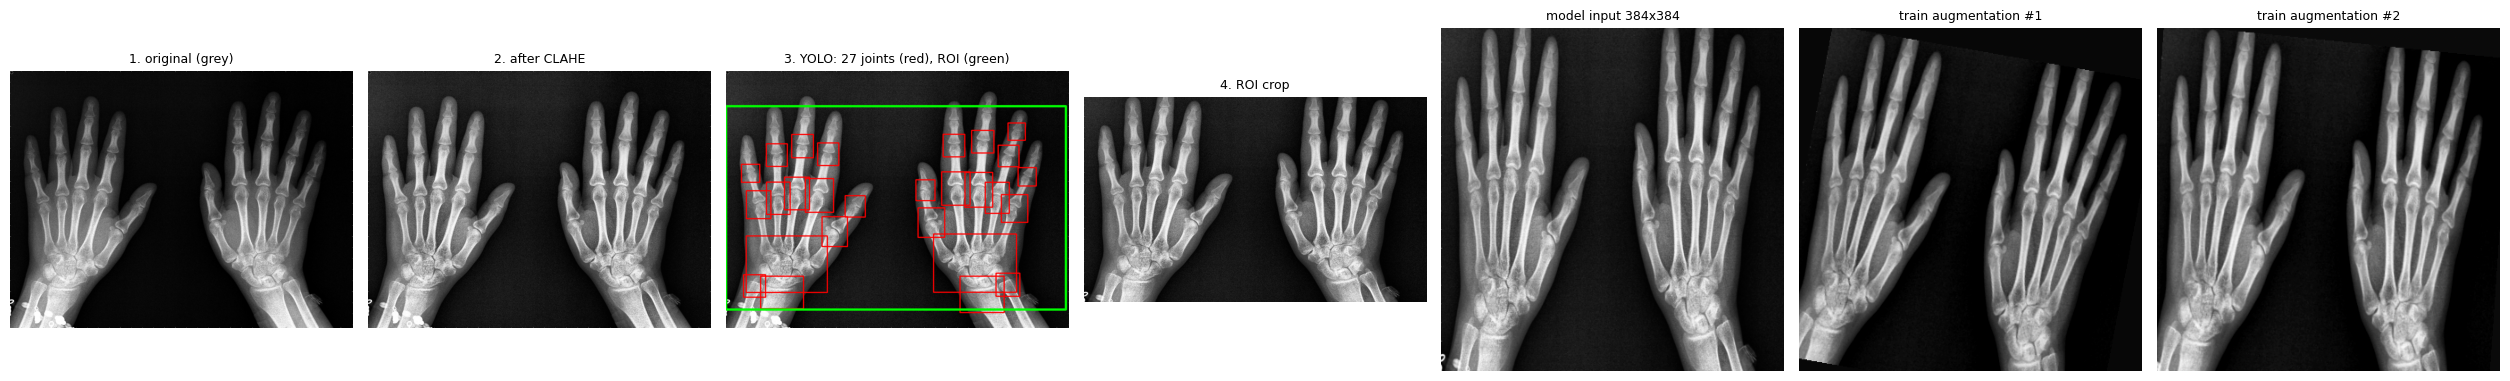

1 image(s) ready. After training, run the last cell of the notebook to get their predictions.


In [29]:
UPLOADED = collect_uploads()
print(f"\n{len(UPLOADED)} image(s) received\n")
STAGES = []
for p_ in UPLOADED:
    try:
        st_ = run_pipeline(p_)
        STAGES.append(st_)
        show_pipeline(st_)
    except Exception as e_:
        print(f"[{os.path.basename(p_)}] could not be processed: {type(e_).__name__}: {e_}")
print(f"{len(STAGES)} image(s) ready. After training, run the last cell of the notebook to get their predictions.")


In [30]:
MODEL_NAME = "efficientnet_b0"
LOSS_TYPE = "coral"
USE_LOSS_CLASS_WEIGHTS = False
HEAD_DROPOUT = 0.4
STOCH_DEPTH = 0.3          # stochastic depth inside the EfficientNet blocks (torchvision default 0.2)

assert LOSS_TYPE in ("ce", "coral")
assert trainData.classes == ["Mild", "Moderate", "Severe"], f"class order is not ordinal: {trainData.classes}"

loss_tag = "coral" if LOSS_TYPE == "coral" else ("ce_w" if USE_LOSS_CLASS_WEIGHTS else "ce")
model_name = f"{MODEL_NAME}_{loss_tag}_grading3_seed{SEED}"


class CoralLayer(nn.Module):
    """One shared score + K-1 ordered biases (CORAL)."""

    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.arange(num_classes - 1, 0, -1).float() / (num_classes - 1))

    def forward(self, x):
        return self.fc(x) + self.bias


def make_head(in_features, num_classes):
    return CoralLayer(in_features, num_classes) if LOSS_TYPE == "coral" else nn.Linear(in_features, num_classes)


def logits_to_probs(outputs):
    outputs = outputs.float()
    if LOSS_TYPE == "coral":
        gt = torch.cummin(torch.sigmoid(outputs), dim=1).values        # P(y > k), forced monotone
        one, zero = torch.ones_like(gt[:, :1]), torch.zeros_like(gt[:, :1])
        cum = torch.cat([one, gt, zero], dim=1)
        return cum[:, :-1] - cum[:, 1:]
    return torch.softmax(outputs, dim=1)


def decode_probs(probs):
    """CORAL: median decoding (number of thresholds with P(y>k) > 0.5). CE: argmax."""
    if LOSS_TYPE == "coral":
        cum = probs.cumsum(1) if torch.is_tensor(probs) else np.cumsum(probs, axis=1)
        return (cum[:, :-1] < 0.5).sum(1)
    return probs.argmax(1)


def build_model(name, num_classes, dropout=HEAD_DROPOUT):
    if name.startswith("efficientnet"):
        try:
            m = getattr(models, name)(weights="DEFAULT", stochastic_depth_prob=STOCH_DEPTH)
        except TypeError:
            m = getattr(models, name)(weights="DEFAULT")
    else:
        m = getattr(models, name)(weights="DEFAULT")
    if name.startswith("resnet"):
        m.fc = nn.Sequential(nn.Dropout(dropout), make_head(m.fc.in_features, num_classes))
        head = m.fc
    elif name.startswith("densenet"):
        m.classifier = nn.Sequential(nn.Dropout(dropout), make_head(m.classifier.in_features, num_classes))
        head = m.classifier
    elif name.startswith("efficientnet"):
        m.classifier[0].p = dropout
        m.classifier[1] = make_head(m.classifier[1].in_features, num_classes)
        head = m.classifier[1]
    elif name.startswith("convnext"):
        m.classifier[2] = make_head(m.classifier[2].in_features, num_classes)
        head = m.classifier[2]
    elif name.startswith("swin"):
        m.head = make_head(m.head.in_features, num_classes)
        head = m.head
    else:
        raise ValueError(f"Unknown model: {name}")

    head_ids = {id(p) for p in head.parameters()}
    backbone = [p for p in m.parameters() if id(p) not in head_ids]
    return m, backbone, list(head.parameters())


seed_all(SEED)
model, backbone_params, head_params = build_model(MODEL_NAME, len(trainData.classes))
model = model.to(device)

HEAD_DIM = len(trainData.classes) - 1 if LOSS_TYPE == "coral" else len(trainData.classes)
model.eval()
with torch.no_grad():
    out = model(torch.randn(2, 3, imgSize, imgSize).to(device))
print(f"Model output shape: {tuple(out.shape)} (expected (2, {HEAD_DIM}))")
model.train()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{model_name}: {round(n_params, 2)}M parameters")


Model output shape: (2, 2) (expected (2, 2))
efficientnet_b0_coral_grading3_seed42: 4.01M parameters


## CBAM

In [31]:
USE_CBAM       = True
CBAM_PLACEMENT = "stages"     # "stages" = after every EfficientNet stage, "last" = only after the last stage
CBAM_REDUCTION = 16
CBAM_KERNEL    = 7
CBAM_GAMMA     = 0.5          # gates are limited to 1 +/- CBAM_GAMMA (they used to saturate at 0 and 2)

assert CBAM_PLACEMENT in ("stages", "last")


class ChannelAttention(nn.Module):
    def __init__(self, ch, reduction=16):
        super().__init__()
        hidden = max(ch // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Conv2d(ch, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, ch, 1, bias=False),
        )
        nn.init.zeros_(self.mlp[2].weight)          # gate = 1 at start (identity)

    def forward(self, x):
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1))
        mx = self.mlp(F.adaptive_max_pool2d(x, 1))
        return 1.0 + CBAM_GAMMA * torch.tanh(avg + mx)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        nn.init.zeros_(self.conv.weight)            # gate = 1 at start (identity)

    def forward(self, x):
        pooled = torch.cat([x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)
        mu = pooled.mean(dim=(2, 3), keepdim=True)
        sd = pooled.std(dim=(2, 3), keepdim=True) + 1e-5
        pooled = (pooled - mu) / sd                 # scale-free input -> the 7x7 conv cannot saturate
        return 1.0 + CBAM_GAMMA * torch.tanh(self.conv(pooled))


class CBAM(nn.Module):
    def __init__(self, ch, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(ch, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        return x * self.sa(x)


def add_cbam(m, name, placement=CBAM_PLACEMENT):
    new = []
    if name.startswith("efficientnet"):
        m.eval()
        chans, x = {}, torch.zeros(1, 3, imgSize, imgSize, device=device)
        with torch.no_grad():
            for i, layer in enumerate(m.features):
                x = layer(x)
                chans[i] = x.shape[1]
        last = len(m.features) - 1
        idxs = list(range(1, last)) if placement == "stages" else [last]
        for i in idxs:
            c = CBAM(chans[i], CBAM_REDUCTION, CBAM_KERNEL)
            m.features[i] = nn.Sequential(m.features[i], c)
            new.append(c)
    elif name.startswith("resnet"):
        names = ["layer1", "layer2", "layer3", "layer4"]
        for ln in (names if placement == "stages" else names[-1:]):
            layer = getattr(m, ln)
            blk = layer[-1]
            ch = blk.bn3.num_features if hasattr(blk, "bn3") else blk.bn2.num_features
            c = CBAM(ch, CBAM_REDUCTION, CBAM_KERNEL)
            setattr(m, ln, nn.Sequential(layer, c))
            new.append(c)
    else:
        raise NotImplementedError(f"CBAM insertion is implemented for efficientnet_* and resnet*, not {name}")
    return new


cbam_modules, cbam_params = [], []
if USE_CBAM:
    n_before = sum(p.numel() for p in model.parameters())
    cbam_modules = add_cbam(model, MODEL_NAME)
    model = model.to(device)
    cbam_params = [p for c in cbam_modules for p in c.parameters()]
    model_name = model_name + "_cbam" + ("" if CBAM_PLACEMENT == "stages" else "_last")

    model.eval()
    with torch.no_grad():
        out = model(torch.randn(2, 3, imgSize, imgSize).to(device))
    model.train()
    added = sum(p.numel() for p in model.parameters()) - n_before
    print(f"CBAM added at {len(cbam_modules)} location(s) ({CBAM_PLACEMENT}) | +{added / 1e6:.3f}M parameters | output {tuple(out.shape)}")
else:
    print("USE_CBAM is False - model unchanged.")


CBAM added at 7 location(s) (stages) | +0.021M parameters | output (2, 2)


In [32]:
REG_TAG = "_v4"
model_name = model_name + DATA_TAG + REG_TAG
print("run name:", model_name)


run name: efficientnet_b0_coral_grading3_seed42_cbam_roi_v4


In [33]:
class CoralLoss(nn.Module):
    """CORAL ordinal loss (binary cross-entropy on the K-1 cumulative targets) with optional label smoothing."""

    def __init__(self, num_classes, smoothing=0.0):
        super().__init__()
        self.register_buffer("thresholds", torch.arange(num_classes - 1))
        self.smoothing = smoothing

    def forward(self, logits, labels):
        levels = (labels.unsqueeze(1) > self.thresholds.unsqueeze(0)).float()
        if self.smoothing > 0:
            levels = levels * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(logits.float(), levels, reduction="none").sum(1).mean()


LABEL_SMOOTHING = 0.05

if LOSS_TYPE == "coral":
    criterion = CoralLoss(len(trainData.classes), smoothing=LABEL_SMOOTHING).to(device)
    loss_desc = f"CORAL (ordinal) + label smoothing {LABEL_SMOOTHING}; class balance comes from the sampler only"
else:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if USE_LOSS_CLASS_WEIGHTS else None, label_smoothing=0.1)
    loss_desc = f"CrossEntropyLoss + label_smoothing 0.1 (class weights: {USE_LOSS_CLASS_WEIGHTS})"


LR_BACKBONE = {
    "resnet18": 1e-4, "resnet50": 1e-4, "densenet169": 1e-4,
    "efficientnet_b0": 2e-4, "convnext_tiny": 5e-5, "swin_t": 5e-5
}
HEAD_LR = 5e-4
WEIGHT_DECAY = 5e-2

# Layer-wise learning rates (EfficientNet): early blocks hold generic edge/texture filters and move slowly,
# late blocks adapt fastest. This is the main protection against memorising ~2000 training images.
LLRD_FACTORS = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.5, 4: 0.5, 5: 0.75, 6: 0.75}
USE_LLRD = MODEL_NAME.startswith("efficientnet")

name_of = {id(p): n for n, p in model.named_parameters()}


def block_index(pname):
    mt = re.match(r"features\.(\d+)\.", pname)
    return int(mt.group(1)) if mt else None


bb_groups = {}
for p in backbone_params:
    f = LLRD_FACTORS.get(block_index(name_of[id(p)]), 1.0) if USE_LLRD else 1.0
    bb_groups.setdefault((f, p.ndim > 1), []).append(p)

param_groups = []
for (f, decay), ps in sorted(bb_groups.items()):
    param_groups.append({"params": ps, "lr": LR_BACKBONE[MODEL_NAME] * f, "weight_decay": WEIGHT_DECAY if decay else 0.0})
for plist, lr_ in ((head_params, HEAD_LR), (cbam_params, LR_BACKBONE[MODEL_NAME])):
    for decay in (True, False):
        ps = [p for p in plist if (p.ndim > 1) == decay]
        if ps:
            param_groups.append({"params": ps, "lr": lr_, "weight_decay": WEIGHT_DECAY if decay else 0.0})
covered = {id(p) for g in param_groups for p in g["params"]}
leftover = [p for p in model.parameters() if id(p) not in covered]
if leftover:
    param_groups.append({"params": leftover, "lr": HEAD_LR, "weight_decay": 0.0})

optimizer = optim.AdamW(param_groups)

EPOCHS_TOTAL, WARMUP_EPOCHS, MIN_LR_FRAC = 30, 2, 0.02


def lr_lambda(ep):
    if ep < WARMUP_EPOCHS:
        return (ep + 1) / WARMUP_EPOCHS
    t = min(1.0, (ep - WARMUP_EPOCHS) / max(1, EPOCHS_TOTAL - WARMUP_EPOCHS))
    return max(MIN_LR_FRAC, 0.5 * (1.0 + math.cos(math.pi * t)))


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Loss: {loss_desc}")
print(f"Optimizer: AdamW | backbone LR {LR_BACKBONE[MODEL_NAME]:.0e} (x{sorted(set(f for f, _ in bb_groups))} layer-wise) | "
      f"head LR {HEAD_LR:.0e} | weight decay {WEIGHT_DECAY} (none on bias/norm/CORAL thresholds)")


Loss: CORAL (ordinal) + label smoothing 0.05; class balance comes from the sampler only
Optimizer: AdamW | backbone LR 2e-04 (x[0.25, 0.5, 0.75, 1.0] layer-wise) | head LR 5e-04 | weight decay 0.05 (none on bias/norm/CORAL thresholds)


In [34]:
import os, shutil
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if os.path.ismount("/content/drive"):
        print("Drive is already mounted.")
    else:
        if os.path.isdir("/content/drive") and os.listdir("/content/drive"):
            shutil.move("/content/drive", "/content/drive_old")
            print("Moved leftover files to /content/drive_old")
        drive.mount("/content/drive")
    OUT_BASE = Path("/content/drive/MyDrive")
    print(os.listdir("/content/drive/MyDrive")[:10])
else:
    OUT_BASE = Path("/kaggle/working") if os.path.isdir("/kaggle/working") else Path("./outputs")
    print("Not running in Colab: checkpoints and results go to", OUT_BASE.resolve())
OUT_BASE.mkdir(parents=True, exist_ok=True)


Drive is already mounted.
['Colab Notebooks', 'Jaishnavi_DS&A_certificates.pdf', 'Jaish_resume.pdf', 'Python for Data Science.pdf', 'Document from Jaishnavi', 'Document from Jaishnavi.pdf', '12th certificate.pdf', '10th certificate.pdf', 'BC certificate.pdf', 'OBC certificate.pdf']


In [35]:
CHECKPOINT_DIR = OUT_BASE / "ra_xray_checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / f"{model_name}_best_checkpoint.pth"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"{model_name}_last_checkpoint.pth"

start_epoch = 0
bestF1 = -1.0
bestLoss = float("inf")
currentPatience = 0
divergeCount = 0
trainLosses, valLosses, valAccs = [], [], []

print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Best:  {CHECKPOINT_PATH}")
print(f"Last:  {LAST_CHECKPOINT_PATH}")


Checkpoint dir: /content/drive/MyDrive/ra_xray_checkpoints
Best:  /content/drive/MyDrive/ra_xray_checkpoints/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_best_checkpoint.pth
Last:  /content/drive/MyDrive/ra_xray_checkpoints/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_last_checkpoint.pth


*Inserted (optional):* keep the YOLO detector weights and joint boxes on Drive so you do not have to train or detect again in a new session.

In [36]:
if DATA_VARIANT == "roi":
    dst = OUT_BASE / "ra_xray_processed"; dst.mkdir(parents=True, exist_ok=True)
    for f in [BOXES_CSV, os.path.join(WORK_DIR, "clahe_roi", "roi_fallbacks.csv"), DETECTOR_WEIGHTS]:
        if f and os.path.exists(f):
            shutil.copy(f, dst); print("copied", f)
else:
    print("skipped (DATA_VARIANT is not roi)")

copied /content/ra_preproc/joint_boxes.csv
copied /content/ra_preproc/clahe_roi/roi_fallbacks.csv
copied /content/drive/MyDrive/ra_xray_yolo/joint_detector_best.pt


In [37]:
import json, copy, math, itertools
from pathlib import Path

RESULTS_DIR = OUT_BASE / "ra_xray_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NOTES = (f"{model_name}, 3-class grading (no Normal), loss={loss_desc}, sqrt-balanced sampler (power {SAMPLER_POWER}), "
             f"augmentation (flip/affine/jitter/blur/cutout), bounded identity-init CBAM, layer-wise LR, EMA weights, "
             f"weight decay {WEIGHT_DECAY}, head dropout {HEAD_DROPOUT}, stochastic depth {STOCH_DEPTH}, "
             f"validation-tuned CORAL cut-points, flip TTA, imgSize {imgSize}, seed {SEED}")

EVAL_TEST = True        # evaluated ONCE at the very end; the test set is never used for any decision
TTA = True              # average the prediction of the image and its horizontal mirror
TUNE_CUTS = True        # re-calibrate the CORAL decision cut-points on the validation set

class_names = trainData.classes
K = len(class_names)
clinical_rank = {"Mild": 0, "Moderate": 1, "Severe": 2}
rank_of_index = np.array([clinical_rank[c] for c in class_names])

# decision cut-point offsets added to the CORAL logits (all zero = plain 0.5 thresholds)
CUT_OFFSETS = np.zeros(max(K - 1, 1), dtype=np.float32)


def adjust_t(out):
    if LOSS_TYPE == "coral":
        return out + torch.as_tensor(CUT_OFFSETS, device=out.device, dtype=out.dtype)
    return out


def probs_from_logits(z):
    zt = torch.from_numpy(np.asarray(z, dtype=np.float32))
    return logits_to_probs(adjust_t(zt)).numpy()


def decode_logits_np(z):
    """Class index from raw logits (no cut-point offsets): leading run of positive CORAL logits, or argmax."""
    if LOSS_TYPE == "coral":
        return np.cumprod(z > 0, axis=1).sum(1).astype(np.int64)
    return z.argmax(1).astype(np.int64)


@torch.no_grad()
def predict_logits(net, loader, tta=False):
    net.eval()
    ys, zs = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        z = net(x).float()
        if tta:
            z = 0.5 * (z + net(torch.flip(x, dims=[3])).float())
        ys.append(y.numpy())
        zs.append(z.cpu().numpy())
    return np.concatenate(ys), np.concatenate(zs)


def predict_loader(loader):
    y, z = predict_logits(model, loader, tta=TTA)
    return y, probs_from_logits(z)


def loss_from_logits(z, y):
    with torch.no_grad():
        return float(criterion(torch.from_numpy(z).to(device), torch.from_numpy(y).to(device)).item())


def expected_calibration_error(y_true, probs, n_bins=10):
    pred = decode_probs(probs)
    conf = probs[np.arange(len(pred)), pred]
    correct = (pred == y_true).astype(float)
    edges, ece = np.linspace(0, 1, n_bins + 1), 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


def compute_metrics(y_true, probs):
    y_pred = decode_probs(probs)
    report = classification_report(y_true, y_pred, labels=list(range(K)), target_names=class_names,
                                   output_dict=True, zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "qwk": float(cohen_kappa_score(rank_of_index[y_true], rank_of_index[y_pred], weights="quadratic")),
        "macro_auc": float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro")),
        "within_one_grade": float((np.abs(y_true - y_pred) <= 1).mean()),
        "mae_grade": float(np.abs(rank_of_index[y_true] - rank_of_index[y_pred]).mean()),
        "ece": expected_calibration_error(y_true, probs),
        "per_class": {c: {"precision": report[c]["precision"],
                          "recall": report[c]["recall"],
                          "f1": report[c]["f1-score"],
                          "support": int(report[c]["support"])}
                      for c in class_names},
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(K))).tolist(),
    }


def to_python(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj.item() if hasattr(obj, "item") else str(obj)


def bootstrap_ci(y_true, probs, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_pred = decode_probs(probs)
    n = len(y_true)
    draws = {"macro_f1": [], "qwk": [], **{f"recall_{c}": [] for c in class_names}}
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        draws["macro_f1"].append(f1_score(yt, yp, average="macro", zero_division=0))
        draws["qwk"].append(cohen_kappa_score(rank_of_index[yt], rank_of_index[yp], weights="quadratic"))
        rec = recall_score(yt, yp, average=None, labels=list(range(K)), zero_division=0)
        for c, r in zip(class_names, rec):
            draws[f"recall_{c}"].append(r)
    return {k: [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))] for k, v in draws.items()}


def print_ci(ci, metrics):
    print("95% bootstrap CIs:")
    for k, (lo, hi) in ci.items():
        point = metrics[k] if k in ("macro_f1", "qwk") else metrics["per_class"][k[len("recall_"):]]["recall"]
        print(f"  {k:<16} {point:.3f}  [{lo:.3f}, {hi:.3f}]")


def macro_f1_fast(y, p, n_cls):
    cm = np.bincount(y * n_cls + p, minlength=n_cls * n_cls).reshape(n_cls, n_cls)
    tp = np.diag(cm).astype(np.float64)
    prec = tp / np.maximum(cm.sum(0), 1)
    rec = tp / np.maximum(cm.sum(1), 1)
    f1 = np.where(prec + rec > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-12), 0.0)
    return float(f1.mean())


def tune_offsets(y, z, grid=None, n_boot=40, seed=SEED, min_gain=0.005):
    """Grid-search CORAL cut-point offsets that maximise bootstrap-averaged macro-F1 on (y, z).
    The bootstrap average + a tiny penalty on large shifts keep it from chasing noise; if the gain is
    smaller than `min_gain` the offsets stay at 0."""
    if grid is None:
        grid = np.round(np.arange(-0.8, 0.81, 0.1), 2)
    k1, n = z.shape[1], len(y)
    y = y.astype(np.int64)
    rng = np.random.default_rng(seed)
    boots = [rng.integers(0, n, n) for _ in range(n_boot)]

    def score(d):
        p = np.cumprod((z + d) > 0, axis=1).sum(1).astype(np.int64)
        return float(np.mean([macro_f1_fast(y[b], p[b], k1 + 1) for b in boots])) - 0.01 * float(np.abs(d).mean())

    base = score(np.zeros(k1, dtype=np.float32))
    best_s, best_d = base, np.zeros(k1, dtype=np.float32)
    for d in itertools.product(grid, repeat=k1):
        d = np.array(d, dtype=np.float32)
        s = score(d)
        if s > best_s:
            best_s, best_d = s, d
    if best_s - base < min_gain:
        return np.zeros(k1, dtype=np.float32), base, base
    return best_d, base, best_s


class ModelEMA:
    """Exponential moving average of the weights (and BatchNorm statistics). The EMA model is what is evaluated and saved."""

    def __init__(self, net, decay=0.995):
        self.module = copy.deepcopy(net).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay = decay
        self.updates = 0

    @torch.no_grad()
    def update(self, net):
        self.updates += 1
        d = min(self.decay, (1.0 + self.updates) / (10.0 + self.updates))
        src = net.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(src[k].detach(), alpha=1.0 - d)
            else:
                v.copy_(src[k])


print("Helpers defined.")


Helpers defined.


In [38]:
patience = 8             # epochs without macro-F1 improvement before stopping
minDelta = 0.002
DIVERGE_MARGIN = 0.15    # stop if val loss stays this far above its minimum ...
DIVERGE_PATIENCE = 3     # ... for this many consecutive epochs (over-fitting guard)
EMA_DECAY = 0.995

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
ema = ModelEMA(model, EMA_DECAY)
print(f"Early stopping patience: {patience} | EMA decay {EMA_DECAY} | GradScaler enabled: {scaler.is_enabled()}")


Early stopping patience: 8 | EMA decay 0.995 | GradScaler enabled: True


In [39]:
if LAST_CHECKPOINT_PATH.exists():
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    ema.module.load_state_dict(checkpoint["ema_state_dict"])
    ema.updates = checkpoint.get("ema_updates", 0)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    if checkpoint.get("scaler_state_dict"):
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"]
    bestF1 = checkpoint.get("best_f1", -1.0)
    bestLoss = checkpoint["best_loss"]
    currentPatience = checkpoint["current_patience"]
    divergeCount = checkpoint.get("diverge_count", 0)
    trainLosses = checkpoint["train_losses"]
    valLosses = checkpoint["val_losses"]
    valAccs = checkpoint["val_accuracies"]
    print(f"Resumed {checkpoint['model_name']} from epoch {start_epoch + 1} | best_f1 {bestF1:.4f} | patience {currentPatience}/{patience}")
else:
    print("No previous checkpoint found. Starting fresh.")


Resumed efficientnet_b0_coral_grading3_seed42_cbam_roi_v4 from epoch 21 | best_f1 0.7143 | patience 8/8


## Training loop (EMA weights, over-fitting guard)


In [40]:
epochs = EPOCHS_TOTAL
use_amp = torch.cuda.is_available()
print(f"Starting training: {start_epoch} -> {epochs}")


def make_checkpoint(epoch, full):
    ck = {
        "epoch": epoch, "model_name": model_name,
        "ema_state_dict": ema.module.state_dict(),
        "best_f1": bestF1, "best_loss": bestLoss, "class_names": trainData.classes,
        "cut_offsets": [0.0] * len(CUT_OFFSETS),
    }
    if full:
        ck.update({
            "model_state_dict": model.state_dict(),
            "ema_updates": ema.updates,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "current_patience": currentPatience, "diverge_count": divergeCount,
            "train_losses": trainLosses, "val_losses": valLosses, "val_accuracies": valAccs,
        })
    return ck


for epoch in range(start_epoch, epochs):
    model.train()
    run_loss, seen, correct = 0.0, 0, 0
    progress_bar = tqdm(trainLoader, desc=f"Epoch {epoch + 1}/{epochs}", leave=False)

    for inputs, labels in progress_bar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        bs = labels.size(0)
        run_loss += loss.item() * bs
        seen += bs
        with torch.no_grad():
            correct += (decode_probs(logits_to_probs(outputs.detach())) == labels).sum().item()
        progress_bar.set_postfix(loss=run_loss / seen, acc=100.0 * correct / seen)

    train_loss = run_loss / seen
    train_acc = 100.0 * correct / seen
    trainLosses.append(train_loss)

    # ---- validation with the EMA weights (smoother and better generalising than the raw weights) ----
    y_v, z_v = predict_logits(ema.module, valLoader, tta=False)
    pred_v = decode_logits_np(z_v)
    val_loss = loss_from_logits(z_v, y_v)
    val_acc = 100.0 * float((pred_v == y_v).mean())
    val_f1 = float(f1_score(y_v, pred_v, average="macro", zero_division=0))
    val_qwk = float(cohen_kappa_score(y_v, pred_v, weights="quadratic"))
    per_class_recall = recall_score(y_v, pred_v, average=None, labels=list(range(K)), zero_division=0)
    valLosses.append(val_loss)
    valAccs.append(val_acc)

    print(f"Epoch {epoch + 1:2d}/{epochs} | train_loss {train_loss:.4f} val_loss {val_loss:.4f} "
          f"gap {val_loss - train_loss:+.4f} | train_acc {train_acc:5.1f}% val_acc {val_acc:5.1f}% | "
          f"macro_f1 {val_f1:.4f} (best {bestF1:.4f}) qwk {val_qwk:.3f} | "
          f"recall {dict(zip(trainData.classes, [round(float(r), 3) for r in per_class_recall]))} | "
          f"lr {optimizer.param_groups[-1]['lr']:.1e}")

    scheduler.step()

    if val_f1 > bestF1 + minDelta:
        bestF1, bestLoss, currentPatience = val_f1, val_loss, 0
        torch.save(make_checkpoint(epoch + 1, full=False), CHECKPOINT_PATH)
        print("  -> NEW BEST: saved checkpoint")
    else:
        currentPatience += 1
        print(f"  -> macro-F1 did not improve ({currentPatience}/{patience})")

    divergeCount = divergeCount + 1 if val_loss > min(valLosses) + DIVERGE_MARGIN else 0
    torch.save(make_checkpoint(epoch + 1, full=True), LAST_CHECKPOINT_PATH)

    if currentPatience >= patience:
        print(f"Early stopping at epoch {epoch + 1} (no improvement)")
        break
    if divergeCount >= DIVERGE_PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}: validation loss is rising while training loss falls (over-fitting)")
        break

print("Training complete.")


Starting training: 0 -> 30


Epoch 1/30:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch  1/30 | train_loss 1.0185 val_loss 0.7207 gap -0.2978 | train_acc  60.2% val_acc  76.1% | macro_f1 0.6552 (best -1.0000) qwk 0.796 | recall {'Mild': 0.958, 'Moderate': 0.188, 'Severe': 0.882} | lr 1.0e-04
  -> NEW BEST: saved checkpoint


Epoch 2/30:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch  2/30 | train_loss 0.8431 val_loss 0.6849 gap -0.1582 | train_acc  69.6% val_acc  76.5% | macro_f1 0.6403 (best 0.6552) qwk 0.799 | recall {'Mild': 0.988, 'Moderate': 0.119, 'Severe': 0.906} | lr 2.0e-04
  -> macro-F1 did not improve (1/8)


...

Epoch 18/30 | train_loss 0.5672 val_loss 0.6475 gap +0.0803 | train_acc  83.6% val_acc  78.9% | macro_f1 0.7050 (best 0.7143) qwk 0.830 | recall {'Mild': 0.971, 'Moderate': 0.248, 'Severe': 0.918} | lr 8.9e-05
  -> macro-F1 did not improve (6/8)


Epoch 19/30:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 19/30 | train_loss 0.5504 val_loss 0.6511 gap +0.1007 | train_acc  83.8% val_acc  78.9% | macro_f1 0.7016 (best 0.7143) qwk 0.831 | recall {'Mild': 0.971, 'Moderate': 0.248, 'Severe': 0.918} | lr 7.8e-05
  -> macro-F1 did not improve (7/8)


Epoch 20/30:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 20/30 | train_loss 0.5417 val_loss 0.6532 gap +0.1115 | train_acc  85.6% val_acc  78.6% | macro_f1 0.7019 (best 0.7143) qwk 0.833 | recall {'Mild': 0.967, 'Moderate': 0.248, 'Severe': 0.918} | lr 6.7e-05
  -> macro-F1 did not improve (8/8)
Early stopping at epoch 20 (no improvement)
Training complete.


## Overfitting analysis: train vs validation losses


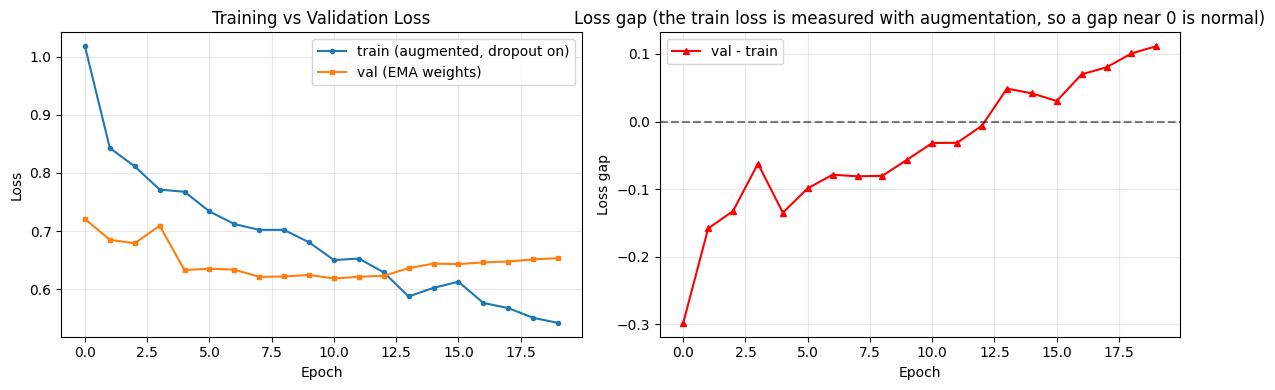

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(trainLosses, label="train (augmented, dropout on)", marker="o", markersize=3)
ax1.plot(valLosses, label="val (EMA weights)", marker="s", markersize=3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

gaps = np.array(valLosses) - np.array(trainLosses)
ax2.plot(gaps, label="val - train", marker="^", markersize=4, color="red")
ax2.axhline(0, color="black", linestyle="--", alpha=0.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss gap")
ax2.set_title("Loss gap (the train loss is measured with augmentation, so a gap near 0 is normal)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Validation results, cut-point calibration and fit report


In [41]:
# ---- load the best EMA weights ----
best_checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_checkpoint["ema_state_dict"])
model = model.to(device).eval()
print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']} | best_f1 {best_checkpoint.get('best_f1', float('nan')):.4f} "
      f"| best_loss {best_checkpoint['best_loss']:.5f}")

# ---- validation logits (with mirror TTA) ----
CUT_OFFSETS[:] = 0.0
y_val, z_val = predict_logits(model, valLoader, tta=TTA)
f1_default = macro_f1_fast(y_val.astype(np.int64), decode_logits_np(z_val), K)

# ---- re-calibrate the CORAL cut-points on validation (fixes the under-predicted middle grade) ----
if LOSS_TYPE == "coral" and TUNE_CUTS:
    d_best, s_base, s_tuned = tune_offsets(y_val, z_val)
    CUT_OFFSETS[:] = d_best
    print(f"Cut-point offsets: {np.round(CUT_OFFSETS, 2).tolist()} | bootstrap macro-F1 {s_base:.4f} -> {s_tuned:.4f}")
best_checkpoint["cut_offsets"] = CUT_OFFSETS.tolist()
torch.save(best_checkpoint, CHECKPOINT_PATH)

probs_val = probs_from_logits(z_val)
metrics_val = compute_metrics(y_val, probs_val)

print("\n=== Validation Results ===")
print(f"macro-F1 with plain 0.5 cut-points: {f1_default:.4f} | with calibrated cut-points: {metrics_val['macro_f1']:.4f}")
print(classification_report(y_val, decode_probs(probs_val), target_names=class_names, digits=4, zero_division=0))
print("Confusion matrix (rows=true, cols=pred):")
print(np.array(metrics_val["confusion_matrix"]))
print(f"Balanced accuracy: {metrics_val['balanced_accuracy']:.4f}")
print(f"Macro-F1:          {metrics_val['macro_f1']:.4f}")
print(f"QWK:               {metrics_val['qwk']:.4f}")
print(f"Macro AUC:         {metrics_val['macro_auc']:.4f}")
print(f"Within one grade:  {metrics_val['within_one_grade']:.4f}")
print(f"MAE (grades):      {metrics_val['mae_grade']:.4f}")

ci_val = bootstrap_ci(y_val, probs_val)
print_ci(ci_val, metrics_val)

# ---- training set WITHOUT augmentation (same weights, same cut-points) ----
trainEvalData = copy.copy(trainData)
trainEvalData.transform = valTransformer
trainEvalLoader = DataLoader(trainEvalData, batch_size=batchSize, shuffle=False,
                             num_workers=2, pin_memory=torch.cuda.is_available())
y_tr, z_tr = predict_logits(model, trainEvalLoader, tta=TTA)
probs_tr = probs_from_logits(z_tr)
metrics_train = compute_metrics(y_tr, probs_tr)
f1_gap = metrics_train["macro_f1"] - metrics_val["macro_f1"]
print("\n=== Train vs validation (best checkpoint, no augmentation) ===")
print(f"Macro-F1  train {metrics_train['macro_f1']:.4f} | val {metrics_val['macro_f1']:.4f} | gap {f1_gap:+.4f}")
print(f"QWK       train {metrics_train['qwk']:.4f} | val {metrics_val['qwk']:.4f} | gap {metrics_train['qwk'] - metrics_val['qwk']:+.4f}")
print(f"Accuracy  train {metrics_train['accuracy']:.4f} | val {metrics_val['accuracy']:.4f}")
print(f"ECE       train {metrics_train['ece']:.4f} | val {metrics_val['ece']:.4f}")


Loaded best checkpoint from epoch 12 | best_f1 0.7143 | best_loss 0.62116
Cut-point offsets: [0.800000011920929, 0.10000000149011612] | bootstrap macro-F1 0.7075 -> 0.7944

=== Validation Results ===
macro-F1 with plain 0.5 cut-points: 0.7051 | with calibrated cut-points: 0.7987
              precision    recall  f1-score   support

        Mild     0.8811    0.8958    0.8884       240
    Moderate     0.6591    0.5743    0.6138       101
      Severe     0.8511    0.9412    0.8939        85

    accuracy                         0.8286       426
   macro avg     0.7971    0.8038    0.7987       426
weighted avg     0.8225    0.8286    0.8244       426

Confusion matrix (rows=true, cols=pred):
[[215  25   0]
 [ 29  58  14]
 [  0   5  80]]
Balanced accuracy: 0.8038
Macro-F1:          0.7987
QWK:               0.8682
Macro AUC:         0.9276
Within one grade:  1.0000
MAE (grades):      0.1714
95% bootstrap CIs:
  macro_f1         0.799  [0.756, 0.838]
  qwk              0.868  [0.835, 0.

In [42]:
# ---- fit report (informational: it prints a verdict, it does not stop anything) ----
FIT_UNDER_TRAIN_F1 = 0.78     # train macro-F1 below this -> the model has not learned enough
FIT_OVER_GAP = 0.10           # train - val macro-F1 above this -> memorising
FIT_MILD_GAP = 0.06

tr_f1, va_f1 = metrics_train["macro_f1"], metrics_val["macro_f1"]
gap_f1 = tr_f1 - va_f1
min_val_ep = int(np.argmin(valLosses)) + 1
print(f"Macro-F1  train(clean) {tr_f1:.3f} | val {va_f1:.3f} | gap {gap_f1:+.3f}")
print(f"best-F1 epoch {best_checkpoint['epoch']} | lowest val-loss epoch {min_val_ep} | epochs run {len(valLosses)}")
print(f"val loss: last {valLosses[-1]:.3f} vs lowest {min(valLosses):.3f}")

if tr_f1 < FIT_UNDER_TRAIN_F1:
    verdict = "UNDER-FIT"
    advice = ("Raise EPOCHS_TOTAL (30 -> 40), raise LR_BACKBONE / HEAD_LR by ~30%, lower WEIGHT_DECAY (0.05 -> 0.03) "
              "or STOCH_DEPTH (0.3 -> 0.2). Do not add regularisation.")
elif gap_f1 > FIT_OVER_GAP:
    verdict = "OVER-FIT"
    advice = ("Raise WEIGHT_DECAY (0.05 -> 0.08), HEAD_DROPOUT (0.4 -> 0.5) or STOCH_DEPTH (0.3 -> 0.4), "
              "lower EPOCHS_TOTAL (30 -> 20), or set SAMPLER_POWER = 0.")
elif gap_f1 > FIT_MILD_GAP:
    verdict = "MILD OVER-FIT (acceptable)"
    advice = "Fine for reporting. For a smaller gap run one more seed or raise STOCH_DEPTH slightly."
else:
    verdict = "GOOD FIT"
    advice = "Train and validation agree. Nothing to change."
print(f"\nVERDICT: {verdict}\n{advice}")


Macro-F1  train(clean) 0.851 | val 0.799 | gap +0.052
best-F1 epoch 12 | lowest val-loss epoch 11 | epochs run 20
val loss: last 0.653 vs lowest 0.618

VERDICT: GOOD FIT
Train and validation agree. Nothing to change.


In [43]:

results_json = {
    "model_name": model_name,
    "best_epoch": best_checkpoint["epoch"],
    "seed": SEED,
    "notes": RUN_NOTES,
    "loss": loss_tag,
    "cut_offsets": CUT_OFFSETS.tolist(),
    "validation": metrics_val,
    "train_clean": {k: metrics_train[k] for k in ("accuracy", "macro_f1", "qwk", "ece")},
    "macro_f1_gap_train_minus_val": f1_gap,
    "validation_bootstrap_ci": ci_val,
    "train_loss_history": trainLosses,
    "val_loss_history": valLosses,
    "val_acc_history": valAccs,
}

results_file = RESULTS_DIR / f"{model_name}_results.json"
with open(results_file, 'w') as f:
    json.dump(results_json, f, indent=2, default=to_python)
print(f"Saved: {results_file}")


probs_file = RESULTS_DIR / f"{model_name}_val_probs.npz"
np.savez_compressed(probs_file, y_true=y_val, probs=probs_val, logits=z_val)
print(f"Saved: {probs_file}")


summary_row = {
    "model_name": model_name,
    "best_epoch": best_checkpoint["epoch"],
    "seed": SEED,
    "loss": loss_tag,
    "val_accuracy": metrics_val["accuracy"],
    "val_balanced_accuracy": metrics_val["balanced_accuracy"],
    "val_macro_f1": metrics_val["macro_f1"],
    "val_qwk": metrics_val["qwk"],
    "val_macro_auc": metrics_val["macro_auc"],
    "val_within_one_grade": metrics_val["within_one_grade"],
    "val_mae_grade": metrics_val["mae_grade"],
    "val_ece": metrics_val["ece"],
    "train_macro_f1_clean": metrics_train["macro_f1"],
    "macro_f1_gap_train_minus_val": f1_gap,
}
for c in class_names:
    summary_row[f"val_recall_{c}"] = metrics_val["per_class"][c]["recall"]

summary_csv = RESULTS_DIR / "all_runs_summary_grading3.csv"
if summary_csv.exists():
    df = pd.read_csv(summary_csv)
    df = df[df["model_name"] != model_name]
    df = pd.concat([df, pd.DataFrame([summary_row])], ignore_index=True)
else:
    df = pd.DataFrame([summary_row])
df = df.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
df.to_csv(summary_csv, index=False)
print(f"Saved: {summary_csv}")
print(f"\nAll runs (sorted by macro-F1):")
print(df[["model_name", "best_epoch", "seed", "val_macro_f1", "val_qwk", "val_recall_Moderate"]])

Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_results.json
Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_val_probs.npz
Saved: /content/drive/MyDrive/ra_xray_results/all_runs_summary_grading3.csv

All runs (sorted by macro-F1):
                                          model_name  best_epoch  seed  \
0  efficientnet_b0_coral_grading3_seed42_cbam_roi_v4          12    42   
1              efficientnet_b0_coral_grading3_seed42          23    42   
2  efficientnet_b0_coral_grading3_seed42_cbam_cla...          16    42   
3                convnext_tiny_coral_grading3_seed42          13    42   
4  efficientnet_b0_coral_grading3_seed42_cbam_cla...          47    42   

   val_macro_f1   val_qwk  val_recall_Moderate  
0      0.798680  0.868194             0.574257  
1      0.776498  0.848141             0.485149  
2      0.771312  0.849042             0.504950  
3      0.757372  0.858640       

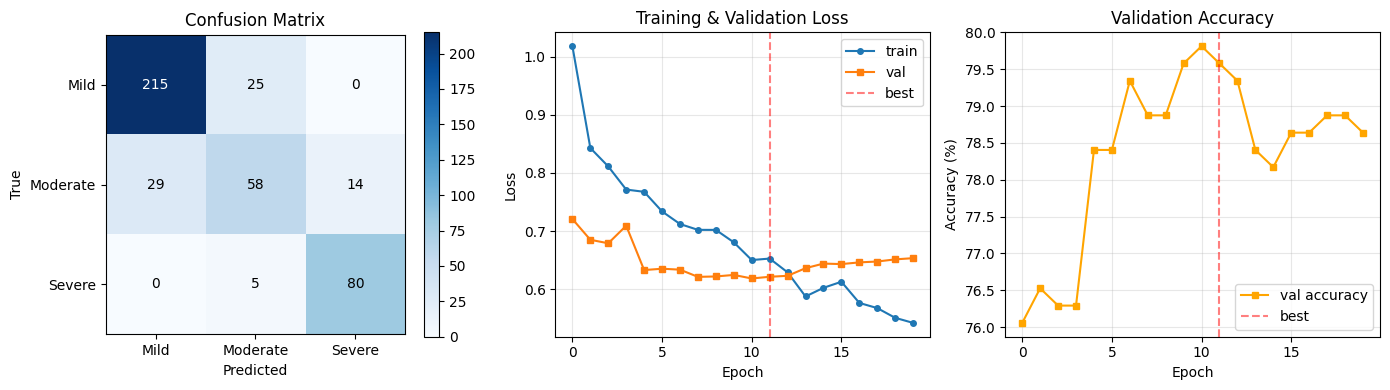

Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_curves.png


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cm = np.array(metrics_val["confusion_matrix"])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names)
axes[0].set_yticklabels(class_names)
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
axes[0].set_title('Confusion Matrix')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

axes[1].plot(trainLosses, label='train', marker='o', markersize=4)
axes[1].plot(valLosses, label='val', marker='s', markersize=4)
axes[1].axvline(best_checkpoint["epoch"] - 1, color='red', linestyle='--', alpha=0.5, label='best')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


axes[2].plot(valAccs, label='val accuracy', marker='s', markersize=4, color='orange')
axes[2].axvline(best_checkpoint["epoch"] - 1, color='red', linestyle='--', alpha=0.5, label='best')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Validation Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
curves_file = RESULTS_DIR / f"{model_name}_curves.png"
plt.savefig(curves_file, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {curves_file}")

## Conformal deferral (clinician safety net)


In [45]:
from sklearn.model_selection import StratifiedShuffleSplit

TARGET_DEFER = 0.10
K = len(class_names)

def conformal_calibrate(y_cal, probs_cal, alpha):

    scores = 1.0 - probs_cal[np.arange(len(y_cal)), y_cal]
    qhat = np.ones(probs_cal.shape[1])
    for k in range(probs_cal.shape[1]):
        s = scores[y_cal == k]
        if len(s) == 0:
            continue
        level = min(1.0, np.ceil((len(s) + 1) * (1 - alpha)) / len(s))
        qhat[k] = np.quantile(s, level, method="higher")
    return qhat

def conformal_decide(probs, qhat):
    sets = (1.0 - probs) <= qhat[None, :]
    answered = sets.sum(1) == 1
    return sets, answered, sets.argmax(1)

def pick_alpha(y_cal, probs_cal, target=TARGET_DEFER):
    grid = np.round(np.arange(0.01, 0.41, 0.01), 2)
    rates = np.array([1 - conformal_decide(probs_cal, conformal_calibrate(y_cal, probs_cal, a))[1].mean()
                      for a in grid])
    return float(grid[int(np.argmin(np.abs(rates - target)))])

def deferral_report(y, probs, qhat):
    sets, answered, pred = conformal_decide(probs, qhat)
    rep_ = {"answered_frac": float(answered.mean()),
            "deferred_frac": float(1 - answered.mean()),
            "set_coverage": float(sets[np.arange(len(y)), y].mean()),
            "acc_answered": float((pred[answered] == y[answered]).mean()) if answered.any() else float("nan"),
            "per_class": {}}
    for k, c in enumerate(class_names):
        m_all, m_ans = (y == k), (y == k) & answered
        rep_["per_class"][c] = {
            "recall_answered": float((pred[m_ans] == k).mean()) if m_ans.any() else float("nan"),
            "frac_answered": float(m_ans.sum() / max(m_all.sum(), 1)),
        }
    return rep_


rows = []
sss = StratifiedShuffleSplit(n_splits=50, test_size=0.5, random_state=SEED)
for cal_idx, ev_idx in sss.split(probs_val, y_val):
    a = pick_alpha(y_val[cal_idx], probs_val[cal_idx])
    r = deferral_report(y_val[ev_idx], probs_val[ev_idx],
                        conformal_calibrate(y_val[cal_idx], probs_val[cal_idx], a))
    row = {"alpha": a, "deferred": r["deferred_frac"], "acc_answered": r["acc_answered"]}
    for c in class_names:
        row[f"recall_{c}"] = r["per_class"][c]["recall_answered"]
        row[f"answered_{c}"] = r["per_class"][c]["frac_answered"]
    rows.append(row)
conf_cv = pd.DataFrame(rows)

base_rec = metrics_val["per_class"]
print(f"Baseline (answer everything) recall: "
      f"{ {c: round(base_rec[c]['recall'], 3) for c in class_names} }")
print(f"\nConformal deferral, mean +/- std over {len(conf_cv)} val splits (target defer {TARGET_DEFER:.0%}):")
for col in conf_cv.columns:
    print(f"  {col:<20} {conf_cv[col].mean():.3f} +/- {conf_cv[col].std():.3f}")


alpha_star = pick_alpha(y_val, probs_val)
qhat_val = conformal_calibrate(y_val, probs_val, alpha_star)
print(f"\nFinal alpha (calibrated on full val): {alpha_star}, per-class qhat: {np.round(qhat_val, 3)}")

conf_file = RESULTS_DIR / f"{model_name}_conformal.json"
with open(conf_file, "w") as f:
    json.dump({"model_name": model_name, "target_defer": TARGET_DEFER, "alpha": alpha_star,
               "qhat": qhat_val.tolist(), "val_split_summary_mean": conf_cv.mean().to_dict(),
               "val_split_summary_std": conf_cv.std().to_dict()}, f, indent=2, default=to_python)
print(f"Saved: {conf_file}")

Baseline (answer everything) recall: {'Mild': 0.896, 'Moderate': 0.574, 'Severe': 0.941}

Conformal deferral, mean +/- std over 50 val splits (target defer 10%):
  alpha                0.249 +/- 0.055
  deferred             0.099 +/- 0.024
  acc_answered         0.823 +/- 0.022
  recall_Mild          0.800 +/- 0.037
  answered_Mild        0.910 +/- 0.041
  recall_Moderate      0.843 +/- 0.046
  answered_Moderate    0.872 +/- 0.034
  recall_Severe        0.868 +/- 0.050
  answered_Severe      0.910 +/- 0.070

Final alpha (calibrated on full val): 0.28, per-class qhat: [       0.27       0.706        0.14]
Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_conformal.json



# Explainable AI + Vision-Language Model (inserted)


In [46]:
import cv2
import copy as _copy

XAI_SPLIT   = "val"
XAI_LAYER   = "last"
XAI_TARGET  = "class"
N_PER_GROUP = 2
N_FAITH     = 40

assert XAI_SPLIT in ("val", "test") and XAI_LAYER in ("last", "fine") and XAI_TARGET in ("class", "severity")

model = model.to(device).eval()
for _p in model.parameters():
    _p.requires_grad_(True)

XAI_MEAN = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
XAI_STD  = torch.tensor(std,  dtype=torch.float32).view(3, 1, 1)


def get_target_layer(m, name, fine=False):
    if name.startswith("efficientnet"):
        return m.features[5] if fine else m.features[-1]
    if name.startswith("resnet"):
        return m.layer3 if fine else m.layer4
    if name.startswith("convnext"):
        return m.features[5] if fine else m.features[-1]
    if name.startswith("densenet"):
        return m.features
    raise NotImplementedError(f"Grad-CAM++ target layer is not defined for {name} (swin_t needs a token-to-grid reshape).")


def class_evidence(out, cls_t):
    out = out.float()
    if LOSS_TYPE == "coral":
        K1 = out.shape[1]
        z_prev = out.gather(1, (cls_t - 1).clamp(min=0)[:, None]).squeeze(1)
        z_curr = out.gather(1, cls_t.clamp(max=K1 - 1)[:, None]).squeeze(1)
        return torch.where(cls_t == 0, -z_curr, torch.where(cls_t == K1, z_prev, -(z_prev + z_curr).abs()))
    return out.gather(1, cls_t[:, None]).squeeze(1)


def grad_campp(x, target=XAI_TARGET, cls=None):
    """Grad-CAM++ for a batch x (already normalised). cls=None -> explain the model's own (calibrated) decision."""
    layer = get_target_layer(model, MODEL_NAME, XAI_LAYER == "fine")
    store = {}
    handle = layer.register_forward_hook(lambda mod, inp, out: store.__setitem__("act", out))
    try:
        model.eval()
        with torch.enable_grad():
            out = adjust_t(model(x.to(device).float()))
            probs = logits_to_probs(out)
            cls_t = decode_probs(probs) if cls is None else torch.as_tensor(cls, device=device).long()
            if target == "severity":
                if LOSS_TYPE == "coral":
                    score = out[:, 0].float().sum()
                else:
                    score = (probs * torch.arange(probs.shape[1], device=device)).sum()
            else:
                score = class_evidence(out, cls_t).sum()
            act = store["act"]
            grad = torch.autograd.grad(score, act)[0]
    finally:
        handle.remove()
    A = act.detach().float()
    g = grad.float()
    g2, g3 = g ** 2, g ** 3
    denom = 2.0 * g2 + A.sum(dim=(2, 3), keepdim=True) * g3
    denom = torch.where(denom != 0, denom, torch.ones_like(denom))
    alpha = g2 / denom
    weights = (alpha * F.relu(g)).sum(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * A).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(imgSize, imgSize), mode="bilinear", align_corners=False).squeeze(1)
    mn, mx = cam.amin(dim=(1, 2), keepdim=True), cam.amax(dim=(1, 2), keepdim=True)
    cam = (cam - mn) / (mx - mn + 1e-8)
    return cam.cpu().numpy(), probs.detach().cpu().numpy(), cls_t.cpu().numpy()


def denorm_img(x):
    return (x.cpu() * XAI_STD + XAI_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()


def overlay_cam(img01, cam, alpha=0.45):
    gray = (img01 * 255).astype(np.uint8)
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (gray * (1 - alpha) + heat * alpha).astype(np.uint8)


def attention_summary(cam):
    H, W = cam.shape
    if float(cam.max()) <= 0:
        return {"where": "none", "spread": "none", "frac_high": 0.0, "edge_mass": 0.0,
                "sentence": "no usable attention signal (the heat-map is empty)", "short": "empty map"}
    r, c = np.unravel_index(int(cam.argmax()), cam.shape)
    vert  = ["upper", "middle", "lower"][min(int(3 * r / H), 2)]
    horiz = ["left", "centre", "right"][min(int(3 * c / W), 2)]
    where = "centre" if (vert == "middle" and horiz == "centre") else f"{vert}-{horiz}" if vert != "middle" else f"middle-{horiz}"
    frac_hi = float((cam >= 0.5).mean())
    spread = "tightly focused" if frac_hi < 0.12 else ("moderately spread" if frac_hi < 0.30 else "diffuse")
    total = float(cam.sum()) + 1e-8
    b = max(int(0.10 * min(H, W)), 1)
    inner = float(cam[b:H - b, b:W - b].sum())
    edge_mass = 1.0 - inner / total
    sentence = (f"the strongest attention is in the {where} of the displayed image; attention is {spread} "
                f"({frac_hi:.0%} of the image above half intensity); {edge_mass:.0%} of the attention lies in the outer 10% border")
    return {"where": where, "spread": spread, "frac_high": frac_hi, "edge_mass": float(edge_mass),
            "sentence": sentence, "short": f"peak {where}, {spread}"}


def pick_cases(y, pred, n=N_PER_GROUP, seed=SEED):
    rng = np.random.default_rng(seed)
    groups = []
    for k in range(len(class_names)):
        for name_, mask in (("correct", (y == k) & (pred == k)), ("wrong", (y == k) & (pred != k))):
            idx = np.where(mask)[0]
            if len(idx):
                groups.append([(int(i), name_) for i in rng.permutation(idx)[:n]])
    out = []
    for r in range(n):
        for g_ in groups:
            if r < len(g_):
                out.append(g_[r])
    return out


print("Grad-CAM++ helpers defined.")


Grad-CAM++ helpers defined.


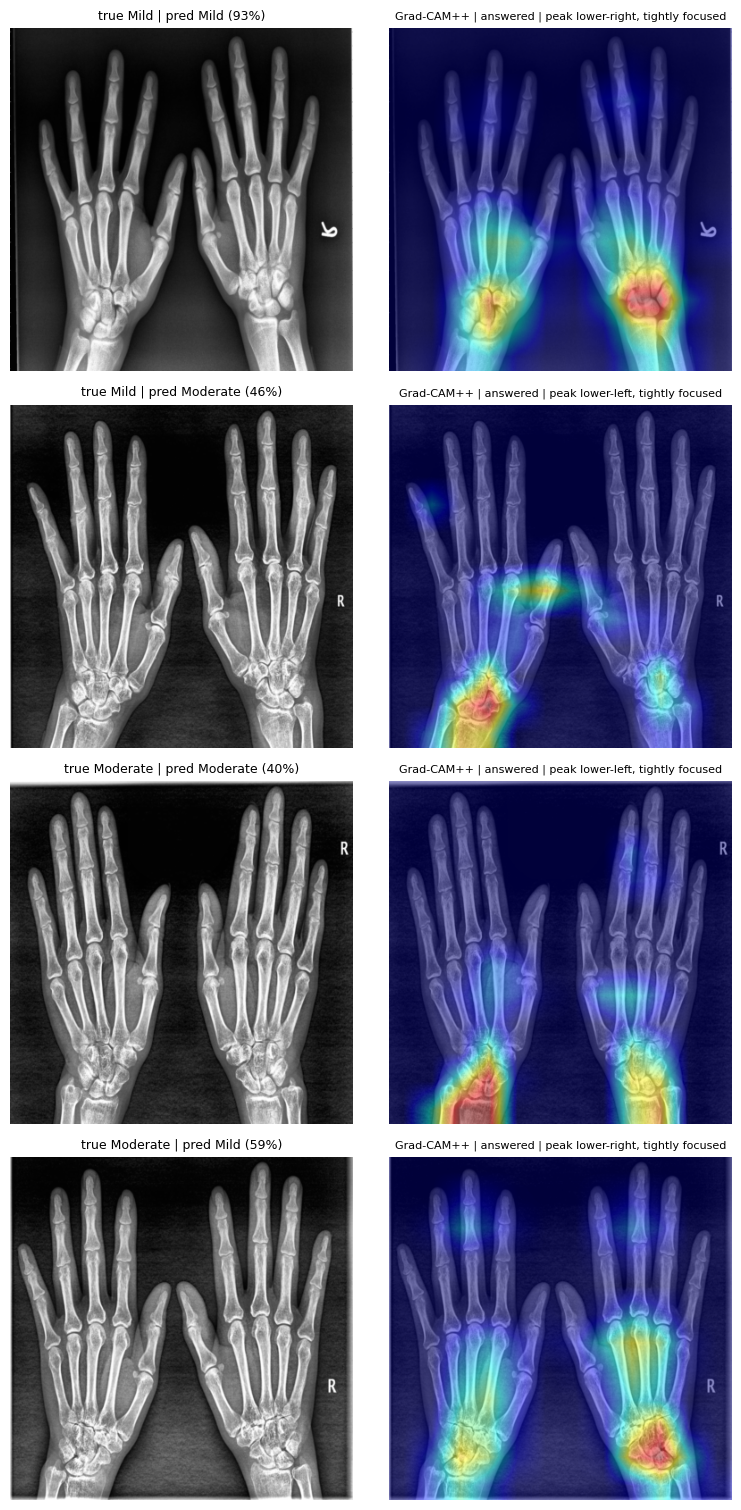

Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_gradcampp_val_1.png


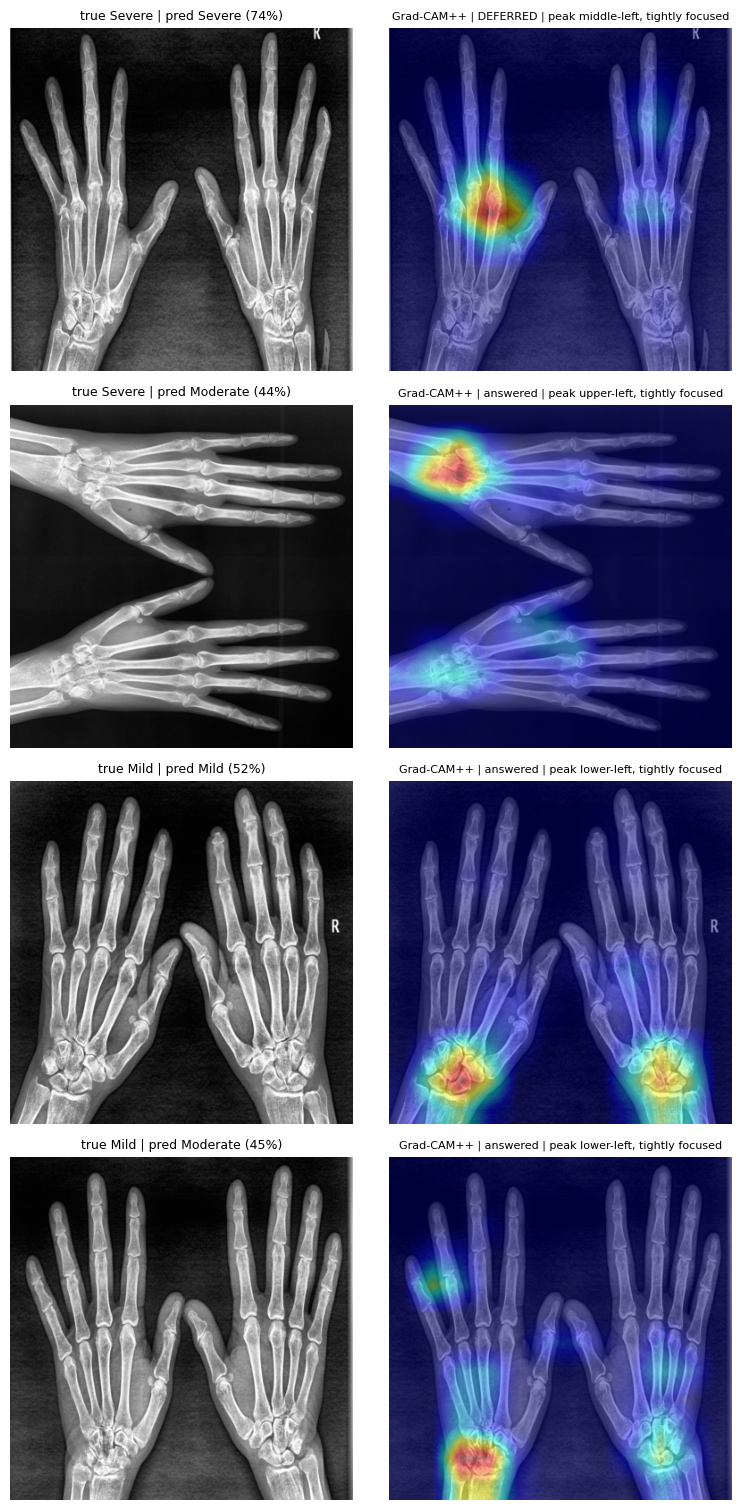

Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_gradcampp_val_2.png


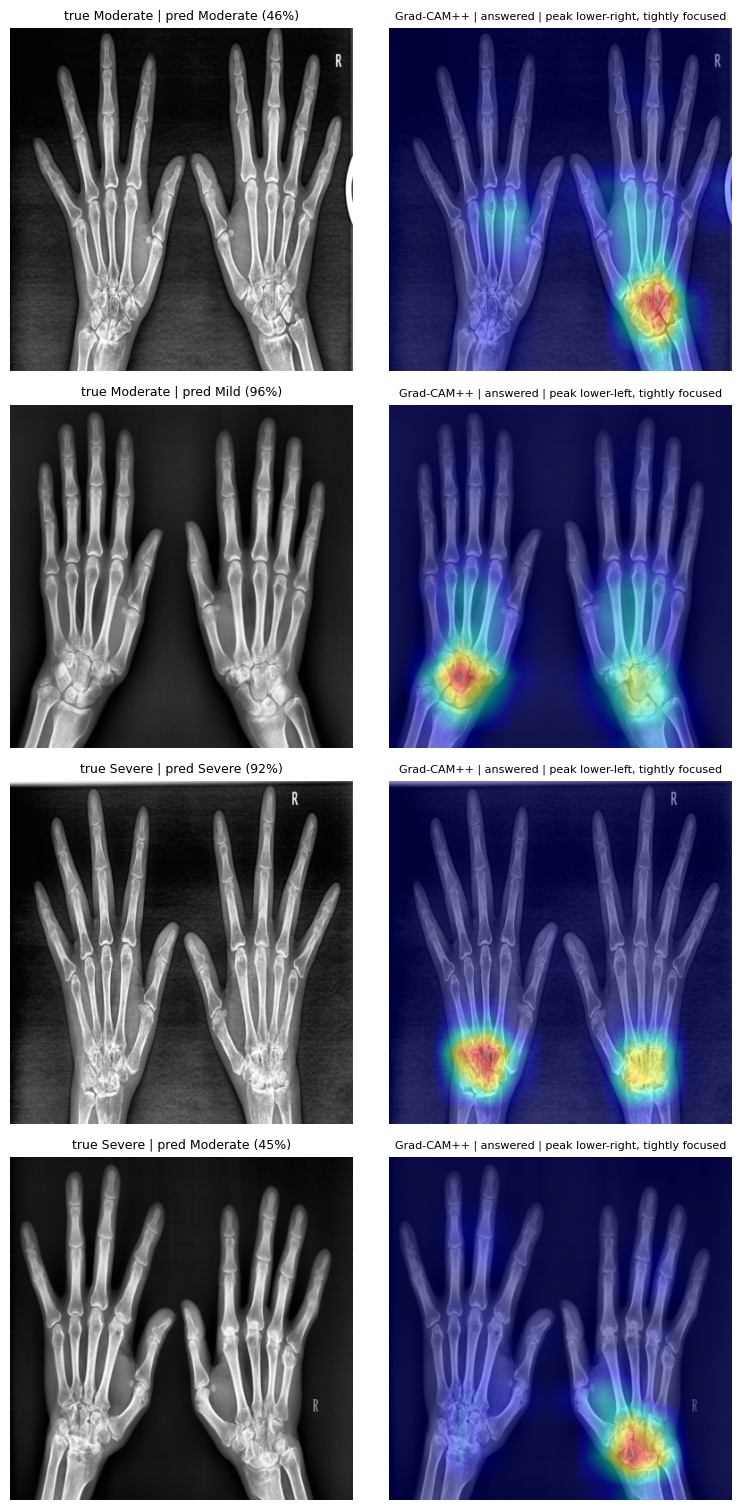

Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_gradcampp_val_3.png


In [47]:
if XAI_SPLIT == "val":
    xai_data, xai_y, xai_probs = valData, y_val, probs_val
else:
    xai_data = testData
    xai_y, xai_probs = predict_loader(testLoader)
assert len(xai_data) == len(xai_y) == len(xai_probs), "dataset / prediction length mismatch"
xai_pred = decode_probs(xai_probs)

if "qhat_val" in globals():
    _, xai_answered, _ = conformal_decide(xai_probs, qhat_val)
else:
    xai_answered = np.ones(len(xai_y), dtype=bool)


def cams_for(indices, bs=8):
    """Grad-CAM++ for the given dataset indices, explaining the same (TTA, calibrated) decision that is reported."""
    cams = []
    idx_all = [int(i) for i in indices]
    for s in range(0, len(idx_all), bs):
        chunk = idx_all[s:s + bs]
        xb = torch.stack([xai_data[i][0] for i in chunk])
        c, _, _ = grad_campp(xb, cls=xai_pred[chunk])
        cams.append(c)
    return np.concatenate(cams), xai_probs[idx_all], xai_pred[idx_all]


xai_cases = pick_cases(xai_y, xai_pred)
case_idx = [i for i, _ in xai_cases]
cams_c, probs_c, cls_c = cams_for(case_idx)

xai_records = []
for (i, grp), cam, pr, k in zip(xai_cases, cams_c, probs_c, cls_c):
    img = denorm_img(xai_data[i][0])
    summ = attention_summary(cam)
    xai_records.append({"idx": int(i), "group": grp, "true": class_names[int(xai_y[i])], "pred": class_names[int(k)],
                        "probs": {c: float(p) for c, p in zip(class_names, pr)}, "conf": float(pr[int(k)]),
                        "answered": bool(xai_answered[i]), "cam": cam, "img": img,
                        "img_u8": (img * 255).astype(np.uint8), "overlay": overlay_cam(img, cam), "summary": summ,
                        "path": str(xai_data.samples[i][0])})


def show_cases(records, per_fig=4):
    for s in range(0, len(records), per_fig):
        chunk = records[s:s + per_fig]
        fig, axes = plt.subplots(len(chunk), 2, figsize=(8, 3.8 * len(chunk)), squeeze=False)
        for row, rec in zip(axes, chunk):
            row[0].imshow(rec["img"])
            row[0].set_title(f"true {rec['true']} | pred {rec['pred']} ({rec['conf']:.0%})", fontsize=9)
            row[1].imshow(rec["overlay"])
            row[1].set_title(f"Grad-CAM++ | {'answered' if rec['answered'] else 'DEFERRED'} | {rec['summary']['short']}", fontsize=8)
            for a in row:
                a.axis("off")
        plt.tight_layout()
        f = RESULTS_DIR / f"{model_name}_gradcampp_{XAI_SPLIT}_{s // per_fig + 1}.png"
        plt.savefig(f, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {f}")


show_cases(xai_records)


In [48]:

DEL_STEPS = 10
HWN = imgSize * imgSize

@torch.no_grad()
def prob_curve(x_img, order, cls_k, steps=DEL_STEPS):
    model.eval()
    batch = []
    for s in range(steps + 1):
        k = int(round(HWN * s / steps))
        m = np.zeros(HWN, dtype=bool)
        m[order[:k]] = True
        xi = x_img.clone()
        xi[:, torch.from_numpy(m.reshape(imgSize, imgSize))] = 0.0
        batch.append(xi)
    p = logits_to_probs(adjust_t(model(torch.stack(batch).to(device).float())))[:, cls_k]
    return p.cpu().numpy()

def curve_area(p):
    return float((p[:-1] + p[1:]).sum() / (2 * (len(p) - 1)))

rng_f = np.random.default_rng(SEED)
faith_idx = rng_f.choice(len(xai_y), size=min(N_FAITH, len(xai_y)), replace=False)
faith_rows = []
for s in range(0, len(faith_idx), 8):
    idx_chunk = faith_idx[s:s + 8]
    cams_f, probs_f, cls_f = cams_for(idx_chunk)
    for j, i in enumerate(idx_chunk):
        k = int(cls_f[j])
        x_img = xai_data[int(i)][0]
        p_cam = prob_curve(x_img, np.argsort(-cams_f[j].ravel(), kind="stable"), k)
        p_rnd = prob_curve(x_img, rng_f.permutation(HWN), k)
        faith_rows.append({"idx": int(i), "pred": class_names[k], "auc_cam": curve_area(p_cam), "auc_rand": curve_area(p_rnd),
                           "p_after_20pct_cam": float(p_cam[2]), "p_after_20pct_rand": float(p_rnd[2]),
                           "edge_mass": attention_summary(cams_f[j])["edge_mass"]})
faith = pd.DataFrame(faith_rows)
win = float((faith["auc_cam"] < faith["auc_rand"]).mean())
print(f"Deletion test on {len(faith)} {XAI_SPLIT} images (lower area = the explanation points at what the model really uses)")
print(f"  area under prob-vs-deleted curve : Grad-CAM++ {faith['auc_cam'].mean():.3f} | random {faith['auc_rand'].mean():.3f}")
print(f"  prob after deleting top 20% pixels: Grad-CAM++ {faith['p_after_20pct_cam'].mean():.3f} | random {faith['p_after_20pct_rand'].mean():.3f}")
print(f"  Grad-CAM++ beats random on {win:.0%} of images")
try:
    from scipy.stats import wilcoxon
    pval = float(wilcoxon(faith["auc_cam"], faith["auc_rand"], alternative="less").pvalue)
    print(f"  Wilcoxon signed-rank (cam < random): p = {pval:.4f}")
except Exception as e:
    pval = None
    print("  (Wilcoxon test skipped:", type(e).__name__, ")")
faithful = bool(faith["auc_cam"].mean() < faith["auc_rand"].mean() and win > 0.5)
print("  -> explanation is", "FAITHFUL (beats random deletion)" if faithful else "NOT clearly faithful: do not use these maps as evidence")

em = float(faith["edge_mass"].mean())
print(f"\nBorder audit: {em:.0%} of attention lies in the outer 10% border (uniform attention would give about 36%)")
if em > 0.50:
    print("  WARNING: the model attends mostly to the image border / background. This suggests a shortcut (scanner frame, text marks, collimation).")
else:
    print("  OK: attention is on the central hand region, not on the border.")

with open(RESULTS_DIR / f"{model_name}_xai_faithfulness.json", "w") as f:
    json.dump({"model_name": model_name, "split": XAI_SPLIT, "layer": XAI_LAYER, "target": XAI_TARGET, "n_images": int(len(faith)),
               "mean_auc_gradcampp": float(faith["auc_cam"].mean()), "mean_auc_random": float(faith["auc_rand"].mean()),
               "gradcampp_beats_random_frac": win, "wilcoxon_p": pval, "faithful": faithful, "mean_edge_attention": em},
              f, indent=2, default=to_python)
print("Saved:", RESULTS_DIR / f"{model_name}_xai_faithfulness.json")

Deletion test on 40 val images (lower area = the explanation points at what the model really uses)
  area under prob-vs-deleted curve : Grad-CAM++ 0.311 | random 0.498
  prob after deleting top 20% pixels: Grad-CAM++ 0.358 | random 0.297
  Grad-CAM++ beats random on 57% of images
  Wilcoxon signed-rank (cam < random): p = 0.0002
  -> explanation is FAITHFUL (beats random deletion)

Border audit: 19% of attention lies in the outer 10% border (uniform attention would give about 36%)
  OK: attention is on the central hand region, not on the border.
Saved: /content/drive/MyDrive/ra_xray_results/efficientnet_b0_coral_grading3_seed42_cbam_roi_v4_xai_faithfulness.json


In [49]:

import importlib, subprocess, sys, gc as _gc

USE_VLM            = True
VLM_ID             = "Qwen/Qwen2-VL-2B-Instruct"
VLM_DTYPE          = "float16"
VLM_MAX_CASES      = 6
VLM_MAX_NEW_TOKENS = 200
FREE_VLM_AFTER     = True

def _ensure_transformers():
    try:
        import transformers
        from packaging.version import Version
        if Version(transformers.__version__) >= Version("4.45"):
            return True
    except Exception:
        pass
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=4.45", "accelerate"], check=False)
    importlib.invalidate_caches()
    try:
        import transformers
        return True
    except Exception as e:
        print("transformers could not be imported:", type(e).__name__)
        return False

vlm, vlm_processor = None, None
if USE_VLM and _ensure_transformers():
    try:
        from transformers import AutoProcessor
        try:
            from transformers import AutoModelForImageTextToText as _AutoVLM
        except ImportError:
            from transformers import AutoModelForVision2Seq as _AutoVLM
        _dt = {"float16": torch.float16, "float32": torch.float32, "bfloat16": torch.bfloat16}[VLM_DTYPE]
        if not torch.cuda.is_available():
            _dt = torch.float32
        try:
            vlm_processor = AutoProcessor.from_pretrained(VLM_ID, min_pixels=128 * 28 * 28, max_pixels=640 * 28 * 28) \
                if "qwen" in VLM_ID.lower() else AutoProcessor.from_pretrained(VLM_ID)
        except TypeError:
            vlm_processor = AutoProcessor.from_pretrained(VLM_ID)
        try:
            vlm = _AutoVLM.from_pretrained(VLM_ID, dtype=_dt, low_cpu_mem_usage=True)
        except TypeError:
            vlm = _AutoVLM.from_pretrained(VLM_ID, torch_dtype=_dt, low_cpu_mem_usage=True)
        vlm = vlm.to(device).eval()
        print(f"VLM loaded: {VLM_ID} ({_dt}) on {device}")
    except Exception as e:
        vlm, vlm_processor = None, None
        print(f"VLM could not be loaded ({type(e).__name__}: {str(e)[:200]}).")
        print("The next cell will use the template report instead. Check internet access / VLM_ID, then re-run this cell.")
else:
    print("VLM skipped (USE_VLM is False or transformers is unavailable): template reports will be used.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

VLM loaded: Qwen/Qwen2-VL-2B-Instruct (torch.float16) on cuda


### VLM helpers, check, reports


In [50]:

DISCLAIMER = ("Decision-support only. The grade must be confirmed by a clinician; the heat-map shows where the model looked, "
              "not proven pathology.")
FINDINGS_LINE = ("Radiographic findings: not assessed here (the vision-language model is a general-purpose model that is not validated "
                 "for reading radiographs). A clinician must confirm the grade.")

def prob_str(rec):
    return ", ".join(f"{c} {rec['probs'][c]:.0%}" for c in class_names)

def facts_block(rec):

    conformal = ("ANSWERED: only one grade is plausible at the chosen confidence" if rec["answered"]
                 else "DEFERRED TO CLINICIAN: more than one grade (or none) is plausible")
    return (f"Model decision: {rec['pred']} ({rec['conf']:.0%}) | probabilities: {prob_str(rec)}\n"
            f"Conformal safety check: {conformal}\n"
            f"Attention (computed from the heat-map): {rec['summary']['sentence']}")

def build_prompt(rec):

    return (
        "You assist a rheumatology team. The image has two panels: on the left a hand/wrist X-ray, on the right the same X-ray with "
        "a colour overlay that shows where an AI grading model looked most (red/yellow = strongest). The colours only show where the "
        "AI looked; they say nothing about disease.\n\n"
        f"AI output (not a diagnosis): grade {rec['pred']} with {rec['conf']:.0%} confidence (probabilities: {prob_str(rec)}).\n"
        f"Safety check: {'answered automatically' if rec['answered'] else 'NOT certain enough, so the case is deferred to a clinician'}.\n"
        f"Heat-map facts: {rec['summary']['sentence']}.\n\n"
        "Write at most 80 words in exactly two short parts:\n"
        "A. Image: which anatomy is visible (hands, wrists, one or both sides) and whether the image quality looks adequate.\n"
        "B. Model: restate the AI grade, its confidence and where it looked, using only the facts above.\n"
        "Do not describe bone or joint abnormalities. Do not mention treatment or medication. Do not name any grade other than the AI grade."
    )

def template_text(rec):
    rel = ("The model was not certain enough, so a clinician should grade this image." if not rec["answered"]
           else "The model is reasonably certain, but a clinician should still confirm the grade.")
    return (f"A. Image: not described (template report; no vision-language model text was used).\n"
            f"B. Model: grade {rec['pred']} ({rec['conf']:.0%}); the heat-map peaks in the {rec['summary']['where']} of the image and is "
            f"{rec['summary']['spread']}. {rel}\n{FINDINGS_LINE}")

_FINDING_WORDS = ("erosion", "deformit", "subluxation", "ankylosis", "osteopenia", "osteoporosis", "narrowing", "swelling",
                  "bone density", "joint space", "joint-space", "bone destruction", "cartilage")
_TREAT_WORDS = ("nsaid", "medication", "treatment", "therapy", "methotrexate", "steroid", "surgery", "drug")
_DISEASE_FROM_HEATMAP = ("inflammation", "damage", "active disease")

def audit_vlm(text, rec, truncated):

    t = text.lower()
    hard, soft = [], []
    if truncated:
        hard.append("cut off at the token limit")
    if rec["pred"].lower() not in t:
        hard.append("does not state the model's grade")
    others = [c for c in class_names if c != rec["pred"] and
              re.search(rf"\b{c.lower()}\b\s+(rheumatoid|arthritis|disease|grade|ra\b|severity)", t)]
    if others:
        hard.append("names another grade: " + ", ".join(others))
    if any(w in t for w in _FINDING_WORDS):
        hard.append("claims radiographic findings (not verifiable)")
    if any(w in t for w in _TREAT_WORDS):
        hard.append("mentions treatment")
    if any(w in t for w in _DISEASE_FROM_HEATMAP):
        hard.append("reads the heat-map as disease")
    if len(text.split()) > 110:
        soft.append("longer than requested")
    return hard, soft

@torch.no_grad()
def vlm_generate(pil_img, prompt):
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
    text = vlm_processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = vlm_processor(text=[text], images=[pil_img], return_tensors="pt")
    inputs = {k: (v.to(vlm.device, dtype=vlm.dtype) if torch.is_floating_point(v) else v.to(vlm.device)) for k, v in inputs.items()}
    out = vlm.generate(**inputs, max_new_tokens=VLM_MAX_NEW_TOKENS, do_sample=False, repetition_penalty=1.1)
    gen = out[:, inputs["input_ids"].shape[1]:]
    truncated = gen.shape[1] >= VLM_MAX_NEW_TOKENS
    return vlm_processor.batch_decode(gen, skip_special_tokens=True)[0].strip(), truncated


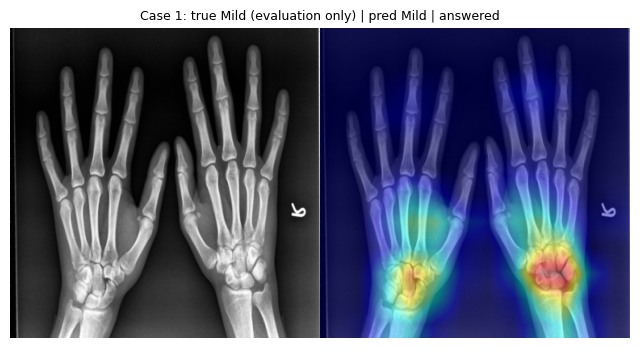

Model decision: Mild (93%) | probabilities: Mild 93%, Moderate 6%, Severe 1%
Conformal safety check: ANSWERED: only one grade is plausible at the chosen confidence
Attention (computed from the heat-map): the strongest attention is in the lower-right of the displayed image; attention is tightly focused (5% of the image above half intensity); 15% of the attention lies in the outer 10% border

--- explanation (Qwen/Qwen2-VL-2B-Instruct) ---
A. Image: Both hands and wrists are visible in the X-ray images. The quality appears to be adequate for medical analysis, as there are no obvious signs of poor resolution or artifacts.

B. Model: The AI grade is "Mild" with 93% confidence. It focuses primarily on the lower-right area of the image, with 5% of attention above half-intensity and 15% in the outer 10% border.
Radiographic findings: not assessed here (the vision-language model is a general-purpose model that is not validated for reading radiographs). A clinician must confirm the grade.

Deci

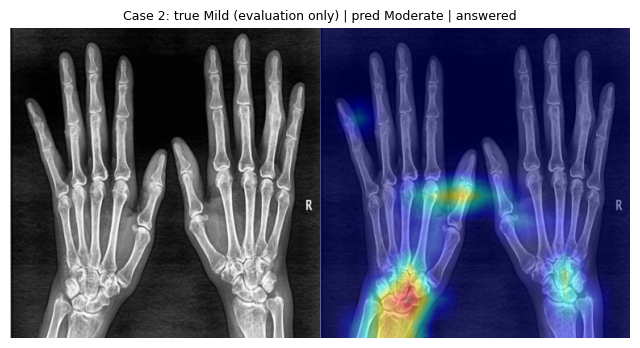

Model decision: Moderate (46%) | probabilities: Mild 31%, Moderate 46%, Severe 23%
Conformal safety check: ANSWERED: only one grade is plausible at the chosen confidence
Attention (computed from the heat-map): the strongest attention is in the lower-left of the displayed image; attention is tightly focused (3% of the image above half intensity); 26% of the attention lies in the outer 10% border

--- explanation (Qwen/Qwen2-VL-2B-Instruct) ---
A. Image: Both hands and wrists are visible in the X-ray images. The image quality appears to be adequate for detailed analysis, as there are no obvious signs of poor resolution or artifacts.

B. Model: The AI grade is "Moderate" with a 46% confidence level. The model concentrated its attention primarily in the lower-left portion of the image, with 3% of the attention being outside the upper half-intensity range. The strongest attention was found in the lower-left area, indicating a focus on the wrist joints.
Radiographic findings: not assessed he

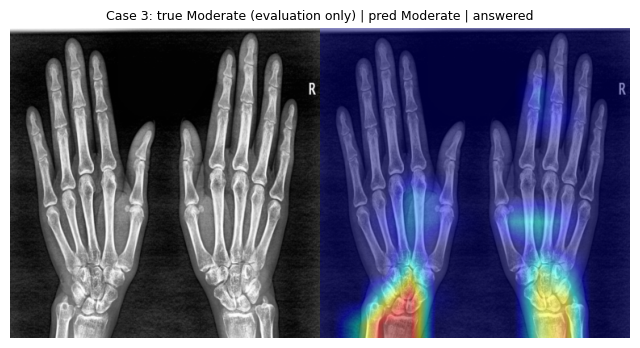

Model decision: Moderate (40%) | probabilities: Mild 46%, Moderate 40%, Severe 13%
Conformal safety check: ANSWERED: only one grade is plausible at the chosen confidence
Attention (computed from the heat-map): the strongest attention is in the lower-left of the displayed image; attention is tightly focused (5% of the image above half intensity); 39% of the attention lies in the outer 10% border

--- explanation (Qwen/Qwen2-VL-2B-Instruct) ---
A. Image: Both hands and wrists are visible in the X-ray images. The image quality appears to be adequate for detailed analysis, as there are no obvious signs of poor resolution or artifacts.

B. Model: The AI grade is "Moderate" with a 40% confidence level. The model concentrated its attention primarily in the lower-left part of the displayed image, with 5% of the image above half-intensity. The majority of attention (39%) was found in the outer 10% border area.
Radiographic findings: not assessed here (the vision-language model is a general-purp

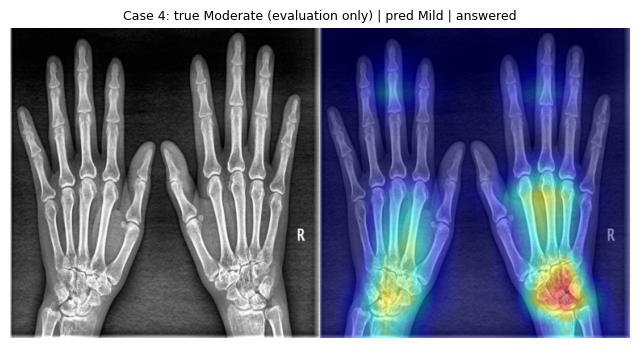

Model decision: Mild (59%) | probabilities: Mild 59%, Moderate 33%, Severe 8%
Conformal safety check: ANSWERED: only one grade is plausible at the chosen confidence
Attention (computed from the heat-map): the strongest attention is in the lower-right of the displayed image; attention is tightly focused (5% of the image above half intensity); 17% of the attention lies in the outer 10% border

--- explanation (Qwen/Qwen2-VL-2B-Instruct) ---
A. Image: Both hands and wrists are visible in the X-ray. The image quality appears to be adequate for detailed analysis, as there are no obvious signs of poor resolution or artifacts.

B. Model: The AI grade is "Mild" with 59% confidence. It focuses primarily on the lower-right area of the image, with 17% of attention concentrated in the outer 10% border. The strongest attention is in the lower-right part of the displayed image.
Radiographic findings: not assessed here (the vision-language model is a general-purpose model that is not validated for re

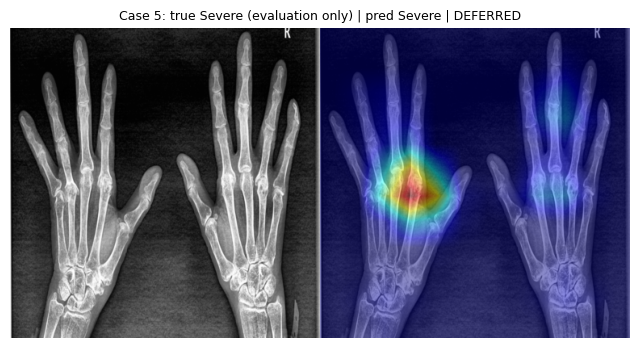

Model decision: Severe (74%) | probabilities: Mild 5%, Moderate 22%, Severe 74%
Conformal safety check: DEFERRED TO CLINICIAN: more than one grade (or none) is plausible
Attention (computed from the heat-map): the strongest attention is in the middle-left of the displayed image; attention is tightly focused (2% of the image above half intensity); 3% of the attention lies in the outer 10% border

--- explanation (Qwen/Qwen2-VL-2B-Instruct) ---
A. Image: Both hands and wrists are visible in the X-ray images. The quality appears adequate for detailed analysis, as there are no obvious signs of poor exposure or focus.

B. Model: The AI grade is "Severe" with 74% confidence. It focuses primarily on the middle-left area of the image, with 2% of attention in the outer 10% border. The strongest attention is in the middle-left region, indicating severe involvement of the joints.
Radiographic findings: not assessed here (the vision-language model is a general-purpose model that is not validated f

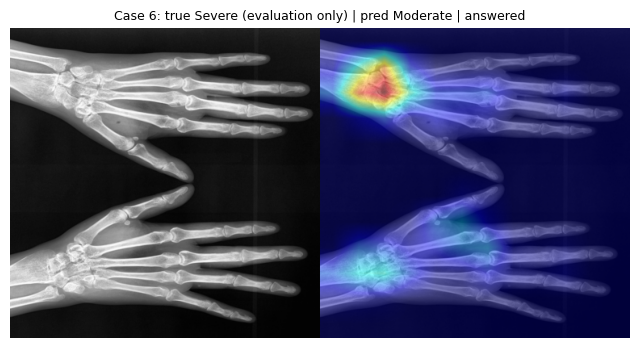

Model decision: Moderate (44%) | probabilities: Mild 18%, Moderate 44%, Severe 38%
Conformal safety check: ANSWERED: only one grade is plausible at the chosen confidence
Attention (computed from the heat-map): the strongest attention is in the upper-left of the displayed image; attention is tightly focused (2% of the image above half intensity); 15% of the attention lies in the outer 10% border

--- explanation (Qwen/Qwen2-VL-2B-Instruct) ---
A. Image: The image shows a pair of hands with their wrist bones visible. The x-rays appear to be of good quality, showing clear details of the bones without any noticeable artifacts or blurring.

B. Model: The AI grade is "Moderate" with a 44% confidence level. The model concentrated its attention primarily in the upper-left portion of the image, with 2% of the attention being outside the first 10% boundary.
Radiographic findings: not assessed here (the vision-language model is a general-purpose model that is not validated for reading radiographs

In [51]:

vlm_reports = []
for n_, rec in enumerate(xai_records[:VLM_MAX_CASES], 1):
    composite = Image.fromarray(np.concatenate([rec["img_u8"], rec["overlay"]], axis=1))
    text, source, raw_text, hard, soft, truncated = "", "template", "", [], [], False
    if vlm is not None:
        try:
            raw_text, truncated = vlm_generate(composite, build_prompt(rec))
            hard, soft = audit_vlm(raw_text, rec, truncated)
            if len(raw_text) >= 20 and not hard:
                text, source = raw_text + "\n" + FINDINGS_LINE, VLM_ID
            else:
                print(f"[case {n_}] VLM text rejected ({'; '.join(hard) or 'empty'}): template report used.")
        except Exception as e:
            print(f"[case {n_}] VLM generation failed ({type(e).__name__}: {str(e)[:150]}); using the template report.")
    if not text:
        text, source = template_text(rec), "template"

    comp_file = RESULTS_DIR / f"{model_name}_report_{n_}.png"
    composite.save(comp_file)
    vlm_reports.append({"case": n_, "image_index": rec["idx"], "image_path": rec["path"], "true_label_for_evaluation_only": rec["true"],
                        "model_prediction": rec["pred"], "probabilities": rec["probs"], "conformal_answered": rec["answered"],
                        "attention": rec["summary"]["sentence"], "explanation_source": source, "explanation": text,
                        "vlm_raw_text": raw_text, "vlm_hard_problems": hard, "vlm_soft_problems": soft, "vlm_truncated": truncated,
                        "composite_image": str(comp_file)})

    plt.figure(figsize=(8, 4.2))
    plt.imshow(composite)
    plt.axis("off")
    plt.title(f"Case {n_}: true {rec['true']} (evaluation only) | pred {rec['pred']} | "
              f"{'answered' if rec['answered'] else 'DEFERRED'}", fontsize=9)
    plt.show()
    print(facts_block(rec))
    print(f"\n--- explanation ({source}) ---\n{text}\n\n{DISCLAIMER}\n" + "=" * 90)

with open(RESULTS_DIR / f"{model_name}_xai_vlm_reports.json", "w") as f:
    json.dump({"model_name": model_name, "split": XAI_SPLIT, "xai_method": "Grad-CAM++", "xai_layer": XAI_LAYER,
               "xai_target": XAI_TARGET, "vlm": VLM_ID if vlm is not None else None, "reports": vlm_reports},
              f, indent=2, default=to_python)
print("Saved:", RESULTS_DIR / f"{model_name}_xai_vlm_reports.json")

if FREE_VLM_AFTER and vlm is not None:
    del vlm, vlm_processor
    vlm, vlm_processor = None, None
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("VLM unloaded from GPU memory.")


## Predict your own uploaded images
Upload with the cell in the *Manual image upload* section, then run this cell. It shows the model input, the Grad-CAM++ map and the grade probabilities for every uploaded image.


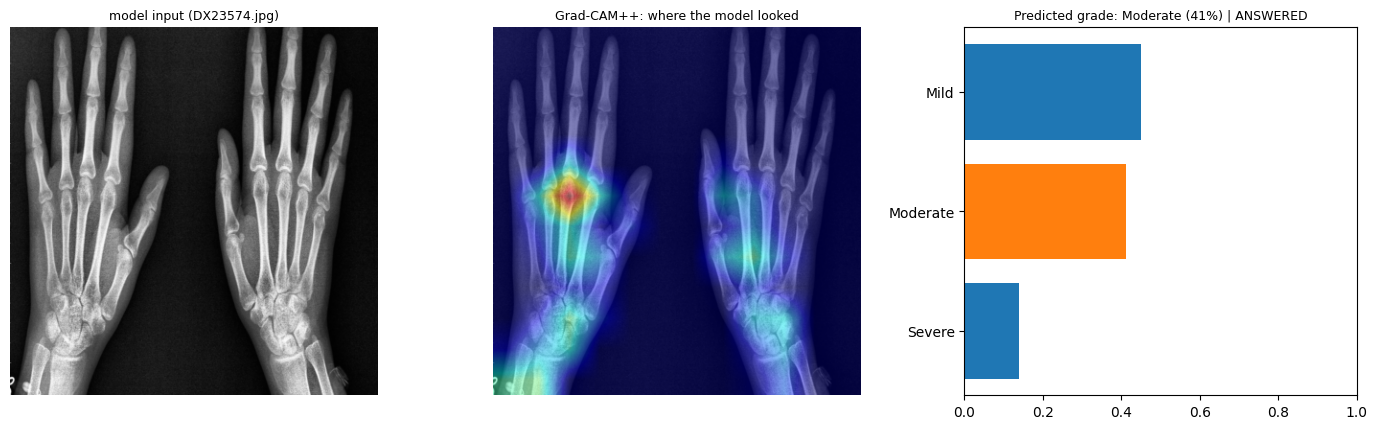

       file    grade  confidence  P(Mild)  P(Moderate)  P(Severe) conformal plausible grades  joints found
DX23574.jpg Moderate       0.411     0.45        0.411      0.139  ANSWERED         Moderate            27

The model grades RA severity only (Mild / Moderate / Severe); it was not trained on normal hands. Decision support only: a clinician must confirm every grade.


In [52]:
# ---------- predictions for the images you uploaded (run the upload cell above first) ----------
if "STAGES" not in globals() or not STAGES:
    print("No uploaded images yet: run the 'Manual image upload' cell, then run this cell again.")
else:
    summary_rows = []
    for st_ in STAGES:
        x_ = st_["tensor"].unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            z_ = model(x_).float()
            if TTA:
                z_ = 0.5 * (z_ + model(torch.flip(x_, dims=[3])).float())
        probs_ = probs_from_logits(z_.cpu().numpy())[0]
        pred_ = int(decode_probs(probs_[None, :])[0])
        cam_, _, _ = grad_campp(st_["tensor"].unsqueeze(0), cls=np.array([pred_]))

        status_, plausible_ = "n/a (run the conformal cell to enable)", ""
        if "qhat_val" in globals():
            sets_, answered_, _ = conformal_decide(probs_[None, :], qhat_val)
            status_ = "ANSWERED" if bool(answered_[0]) else "DEFERRED to clinician"
            plausible_ = ", ".join(class_names[k_] for k_ in np.where(sets_[0])[0]) or "none"

        img_ = denorm_img(st_["tensor"])
        fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
        axes[0].imshow(img_)
        axes[0].set_title(f"model input ({st_['name']})", fontsize=9)
        axes[1].imshow(overlay_cam(img_, cam_[0]))
        axes[1].set_title("Grad-CAM++: where the model looked", fontsize=9)
        colors_ = ["tab:orange" if k_ == pred_ else "tab:blue" for k_ in range(K)]
        axes[2].barh(class_names, probs_, color=colors_)
        axes[2].set_xlim(0, 1)
        axes[2].invert_yaxis()
        axes[2].set_title(f"Predicted grade: {class_names[pred_]} ({probs_[pred_]:.0%}) | {status_}", fontsize=9)
        for a_ in axes[:2]:
            a_.axis("off")
        plt.tight_layout()
        plt.show()
        for note_ in st_["notes"]:
            print("  note:", note_)

        summary_rows.append({"file": st_["name"], "grade": class_names[pred_], "confidence": round(float(probs_[pred_]), 3),
                             **{f"P({c})": round(float(p), 3) for c, p in zip(class_names, probs_)},
                             "conformal": status_, "plausible grades": plausible_, "joints found": st_.get("n_joints", "n/a")})
    print(pd.DataFrame(summary_rows).to_string(index=False))
    print("\nThe model grades RA severity only (Mild / Moderate / Severe); it was not trained on normal hands. "
          "Decision support only: a clinician must confirm every grade.")


## Test set evaluation

In [53]:
if EVAL_TEST:
    y_test, z_test = predict_logits(model, testLoader, tta=TTA)
    probs_test = probs_from_logits(z_test)
    metrics_test = compute_metrics(y_test, probs_test)
    ci_test = bootstrap_ci(y_test, probs_test)

    print("\n=== TEST SET RESULTS (cut-points and checkpoint chosen on validation only) ===")
    print(classification_report(y_test, decode_probs(probs_test), target_names=class_names, digits=4, zero_division=0))
    print("Confusion matrix (rows=true, cols=pred):")
    print(np.array(metrics_test["confusion_matrix"]))
    print(f"Accuracy:         {metrics_test['accuracy']:.4f}")
    print(f"Macro-F1:         {metrics_test['macro_f1']:.4f}")
    print(f"QWK:              {metrics_test['qwk']:.4f}")
    print(f"Within one grade: {metrics_test['within_one_grade']:.4f}")
    print(f"MAE (grades):     {metrics_test['mae_grade']:.4f}")
    print_ci(ci_test, metrics_test)
    print(f"Val -> test macro-F1: {metrics_val['macro_f1']:.3f} -> {metrics_test['macro_f1']:.3f} "
          f"(a drop of more than ~0.05 would mean the validation choices over-fitted the validation set)")

    conf_test = deferral_report(y_test, probs_test, qhat_val)
    print(f"\n=== TEST: conformal deferral (alpha={alpha_star}, calibrated on val) ===")
    print(f"Answered: {conf_test['answered_frac']:.1%}  Deferred: {conf_test['deferred_frac']:.1%}  "
          f"Accuracy on answered: {conf_test['acc_answered']:.3f}  Set coverage: {conf_test['set_coverage']:.3f}")
    for c in class_names:
        pc = conf_test["per_class"][c]
        print(f"  {c:<9} recall on answered {pc['recall_answered']:.3f} | share of class answered {pc['frac_answered']:.1%}")
    test_file = RESULTS_DIR / f"{model_name}_test_results.json"
    with open(test_file, "w") as f:
        json.dump({"model_name": model_name, "cut_offsets": CUT_OFFSETS.tolist(), "test": metrics_test, "test_bootstrap_ci": ci_test,
                   "conformal": {"alpha": alpha_star, "qhat": qhat_val.tolist(), **conf_test}},
                  f, indent=2, default=to_python)
    print(f"Saved: {test_file}")
    np.savez_compressed(RESULTS_DIR / f"{model_name}_test_probs.npz", y_true=y_test, probs=probs_test, logits=z_test)
else:
    print("Set EVAL_TEST = True to evaluate the test set.")



=== TEST SET RESULTS (cut-points and checkpoint chosen on validation only) ===
              precision    recall  f1-score   support

        Mild     0.8750    0.8967    0.8857       242
    Moderate     0.6364    0.4757    0.5444       103
      Severe     0.7570    0.9310    0.8351        87

    accuracy                         0.8032       432
   macro avg     0.7561    0.7678    0.7551       432
weighted avg     0.7943    0.8032    0.7941       432

Confusion matrix (rows=true, cols=pred):
[[217  23   2]
 [ 30  49  24]
 [  1   5  81]]
Accuracy:         0.8032
Macro-F1:         0.7551
QWK:              0.8387
Within one grade: 0.9931
MAE (grades):     0.2037
95% bootstrap CIs:
  macro_f1         0.755  [0.712, 0.797]
  qwk              0.839  [0.797, 0.875]
  recall_Mild      0.897  [0.856, 0.934]
  recall_Moderate  0.476  [0.381, 0.573]
  recall_Severe    0.931  [0.875, 0.978]
Val -> test macro-F1: 0.799 -> 0.755 (a drop of more than ~0.05 would mean the validation choices over-